# Coil Centering Scan Notebook

This notebook scans how well the bias-corrected magnetic-axis estimate recovers the actual transformed field-coil geometry as a function of:

- Hall probe count/layout
- Coil current
- Applied shifts and tilts
- Optional magnetic field noise

It uses the same core definitions as `coil_centering_full.jl` and `tilt_shift.jl`:

- geometric center = segment-length-weighted centroid
- geometric orientation = weighted best-fit plane normal
- magnetic `z`/tilt = `B_R` zero-crossing sinusoid
- magnetic `x/y` = local `B_phi` minimization
- bias correction = forward-model bias subtraction using assumed physical coil model


In [ ]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "../.."))

using GeneralizedPerturbedEquilibrium
using LinearAlgebra
using Statistics
using Printf
using Random

for pkg in ["DataFrames", "CSV", "CairoMakie"]
    try
        @eval using $(Symbol(pkg))
    catch
        Pkg.add(pkg)
        @eval using $(Symbol(pkg))
    end
end

const FT = GeneralizedPerturbedEquilibrium.ForcingTerms
const compute_biot_savart_boundary! = FT.compute_biot_savart_boundary!
const read_coil_dat = FT.read_coil_dat

println("Notebook setup complete.")

  Activating project at `~/Documents/GitHub/JULIA_GPEC`
    Updating registry at `~/.julia/registries/FuseRegistry`
    Updating git-repo `https://github.com/ProjectTorreyPines/FuseRegistry.jl.git`
    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed Graphics ─── v1.1.3
   Installed CairoMakie ─ v0.15.9
   Installed Cairo ────── v1.1.1
      Compat entries added for CairoMakie
    Updating `~/Documents/GitHub/JULIA_GPEC/Project.toml`
⌃ [13f3f980] + CairoMakie v0.15.9
    Updating `~/Documents/GitHub/JULIA_GPEC/Manifest.toml`
  [159f3aea] + Cairo v1.1.1
⌃ [13f3f980] + CairoMakie v0.15.9
  [a2bd30eb] + Graphics v1.1.3
        Info Packages marked with ⌃ have new versions available and may be upgradable.


Notebook setup complete.


Precompiling packages...
   1007.6 ms  ✓ Graphics
   4723.0 ms  ✓ Cairo
  38673.9 ms  ✓ CairoMakie
  3 dependencies successfully precompiled in 47 seconds. 628 already precompiled.


## User configuration

Edit these paths and scan settings first.

In [ ]:
set_theme!(Theme(font="TeX Gyre Termes",fontsize=24))

In [ ]:
# Paths
BASE_DIR = @__DIR__
PHYSICAL_COIL_FILE = joinpath(BASE_DIR, "sparc_pf1u.dat")
SCAN_OUTPUT_DIR = joinpath(BASE_DIR, "coil_centering_scan_outputs")
mkpath(SCAN_OUTPUT_DIR)

# Base transform used by tilt_shift.jl. Scans below multiply these by scale factors.
BASE_SHIFT_X = 0.01   # m
BASE_SHIFT_Y = 0.03   # m
BASE_SHIFT_Z = 0.05   # m
BASE_TILT_X_DEG = 1
BASE_TILT_Y_DEG = 5
BASE_TILT_Z_DEG = 0.0

# Hall-probe shell radii and z-spans
HALL_R_INNER_FRAC = 0.40
HALL_R_OUTER_FRAC = 0.50
HALL_Z_HALFSPAN_INNER_M = 0.60
HALL_Z_HALFSPAN_OUTER_M = 0.40

# Analysis settings
TILT_CALIBRATION_RADIUS_M = NaN
BR_ZERO_NOISE_FRAC = 0.0
XY_MIN_STEP0_M = 0.050
XY_MIN_TOL_M = 1e-8
BIAS_CORRECTION_N_ITER = 4
BIAS_CORRECTION_DAMPING = 0.6

# Optional synthetic measurement noise added to each field component.
# If these are both zero, current will mostly not matter because Biot-Savart is linear in current.
B_NOISE_ABS_T = 0.0       # absolute Tesla noise
B_NOISE_REL = 0.0         # relative to median |B|
RNG_SEED = 1234

# Scan grids. Keep these small first; each row does multiple Biot-Savart solves.
#hall_layouts = [
#    (name="coarse",  nphi_i=12, nz_i=10, nphi_o=10, nz_o=6),
#    (name="medium",  nphi_i=24, nz_i=22, nphi_o=20, nz_o=10),
#    (name="dense",   nphi_i=36, nz_i=30, nphi_o=30, nz_o=16),
#    ]
hall_layouts = [
    (name="coarse",  nphi_i=6, nz_i=5, nphi_o=5, nz_o=3),
    (name="medium",  nphi_i=12, nz_i=10, nphi_o=10, nz_o=6),
    (name="dense",   nphi_i=24, nz_i=22, nphi_o=20, nz_o=10),
]

coil_currents_A = [10.0, 100.0, 1000.0]
transform_scales = [0.0, 0.25, 0.50, 1.0]

println("Physical coil: ", PHYSICAL_COIL_FILE)
println("Scan output dir: ", SCAN_OUTPUT_DIR)

Physical coil: /Users/bursche/Documents/GitHub/JULIA_GPEC/examples/Br_3D_example/sparc_pf1u.dat
Scan output dir: /Users/bursche/Documents/GitHub/JULIA_GPEC/examples/Br_3D_example/coil_centering_scan_outputs


## Helper functions

This cell contains the transform utility, geometric pose calculation, Hall field generation, magnetic-axis analysis, and bias correction.

In [ ]:
wmean(x, w) = sum(w) <= 0 ? mean(x) : sum(w .* x) / sum(w)

function meanfinite(v)
    u = filter(isfinite, collect(v))
    isempty(u) ? NaN : mean(u)
end

function zcrossings(vals, z)
    out = Float64[]
    for i in 1:(length(vals)-1)
        vals[i] == 0 && push!(out, z[i])
        vals[i] * vals[i+1] < 0 || continue
        t = vals[i] / (vals[i] - vals[i+1])
        push!(out, z[i] + t * (z[i+1] - z[i]))
    end
    out
end

function rotation_x(theta)
    c, s = cos(theta), sin(theta)
    [1.0 0.0 0.0; 0.0 c -s; 0.0 s c]
end

function rotation_y(theta)
    c, s = cos(theta), sin(theta)
    [c 0.0 s; 0.0 1.0 0.0; -s 0.0 c]
end

function rotation_z(theta)
    c, s = cos(theta), sin(theta)
    [c -s 0.0; s c 0.0; 0.0 0.0 1.0]
end

build_rotation_matrix(tx_deg, ty_deg, tz_deg) = rotation_z(deg2rad(tz_deg)) * rotation_y(deg2rad(ty_deg)) * rotation_x(deg2rad(tx_deg))

function read_raw_coil_file(filepath::String)
    isfile(filepath) || error("Input coil file not found: $filepath")
    lines = readlines(filepath)
    isempty(lines) && error("Coil file is empty: $filepath")
    header = lines[1]
    x = Float64[]; y = Float64[]; z = Float64[]
    for i in 2:length(lines)
        s = strip(lines[i])
        isempty(s) && continue
        tok = split(s)
        length(tok) >= 3 || continue
        try
            push!(x, parse(Float64, tok[1]))
            push!(y, parse(Float64, tok[2]))
            push!(z, parse(Float64, tok[3]))
        catch
        end
    end
    return header, x, y, z
end

function write_raw_coil_file(filepath::String, header::String, x, y, z)
    open(filepath, "w") do io
        println(io, header)
        for i in eachindex(x)
            @printf(io, "  %14.7e   %14.7e   %14.7e\n", x[i], y[i], z[i])
        end
    end
end

function is_closed_curve(x, y, z; tol=1e-12)
    length(x) >= 2 || return false
    return (x[1]-x[end])^2 + (y[1]-y[end])^2 + (z[1]-z[end])^2 <= tol^2
end

function raw_segment_midpoints_lengths(x, y, z)
    N = length(x)
    N >= 2 || error("Need at least two coil points")
    closed = is_closed_curve(x, y, z)
    lastseg = closed ? N-1 : N
    mx = Float64[]; my = Float64[]; mz = Float64[]; w = Float64[]
    for i in 1:lastseg
        j = i == N ? 1 : i+1
        dlx = x[j]-x[i]; dly = y[j]-y[i]; dlz = z[j]-z[i]
        ds = sqrt(dlx^2+dly^2+dlz^2)
        ds <= 0 && continue
        push!(mx, 0.5*(x[i]+x[j]))
        push!(my, 0.5*(y[i]+y[j]))
        push!(mz, 0.5*(z[i]+z[j]))
        push!(w, ds)
    end
    return mx, my, mz, w
end

function plane_basis_from_normal(n)
    ref = abs(n[3]) < 0.9 ? [0.0,0.0,1.0] : [1.0,0.0,0.0]
    e1 = normalize(cross(ref, n))
    e2 = cross(n, e1)
    return e1, e2
end

function raw_pose_from_points(x, y, z)
    mx, my, mz, w = raw_segment_midpoints_lengths(x, y, z)
    W = sum(w)
    cx = sum(w .* mx) / W
    cy = sum(w .* my) / W
    cz = sum(w .* mz) / W
    P = hcat(mx .- cx, my .- cy, mz .- cz)
    Pw = P .* sqrt.(w)
    _, _, V = svd(Pw)
    n = Vector(V[:,3])
    n[3] < 0 && (n = -n)
    tx = atand(-n[2], n[3])
    ty = atand( n[1], n[3])
    return (x0=cx, y0=cy, z0=cz, tilt_x=tx, tilt_y=ty, normal=n)
end

function transform_coil_file(input_file, output_file; shift_x=0.0, shift_y=0.0, shift_z=0.0, tilt_x_deg=0.0, tilt_y_deg=0.0, tilt_z_deg=0.0)
    header, x, y, z = read_raw_coil_file(input_file)
    pose = raw_pose_from_points(x, y, z)
    R = build_rotation_matrix(tilt_x_deg, tilt_y_deg, tilt_z_deg)
    xnew = similar(x); ynew = similar(y); znew = similar(z)
    c = [pose.x0, pose.y0, pose.z0]
    for i in eachindex(x)
        q = R * ([x[i], y[i], z[i]] - c) + c + [shift_x, shift_y, shift_z]
        xnew[i] = q[1]; ynew[i] = q[2]; znew[i] = q[3]
    end
    write_raw_coil_file(output_file, header, xnew, ynew, znew)
    return output_file
end

function load_coils(file; current_A=100.0)
    cs = read_coil_dat(file)
    cs.currents .= current_A
    return [cs]
end

function segment_midpoints_lengths(coils)
    mx = Float64[]; my = Float64[]; mz = Float64[]; w = Float64[]
    for cs in coils, j in 1:cs.ncoil, k in 1:cs.s, l in 1:(cs.nsec-1)
        x1 = cs.x[j,k,l];   y1 = cs.y[j,k,l];   z1 = cs.z[j,k,l]
        x2 = cs.x[j,k,l+1]; y2 = cs.y[j,k,l+1]; z2 = cs.z[j,k,l+1]
        ds = sqrt((x2-x1)^2 + (y2-y1)^2 + (z2-z1)^2)
        ds <= 0 && continue
        push!(mx, 0.5*(x1+x2)); push!(my, 0.5*(y1+y2)); push!(mz, 0.5*(z1+z2)); push!(w, ds)
    end
    return mx, my, mz, w
end

function collect_coil_xyz(coils)
    x = Float64[]; y = Float64[]; z = Float64[]
    for cs in coils, j in 1:cs.ncoil, k in 1:cs.s
        append!(x, vec(cs.x[j,k,:])); append!(y, vec(cs.y[j,k,:])); append!(z, vec(cs.z[j,k,:]))
    end
    return x, y, z
end

function axis_from_coil(coils)
    mx, my, mz, w = segment_midpoints_lengths(coils)
    W = sum(w)
    cx = sum(w .* mx) / W
    cy = sum(w .* my) / W
    cz = sum(w .* mz) / W
    P = hcat(mx .- cx, my .- cy, mz .- cz)
    Pw = P .* sqrt.(w)
    _, _, V = svd(Pw)
    n = Vector(V[:,3])
    n[3] < 0 && (n = -n)
    tx = atand(-n[2], n[3])
    ty = atand( n[1], n[3])
    e1, e2 = plane_basis_from_normal(n)
    dx = mx .- cx; dy = my .- cy; dz = mz .- cz
    u = dx .* e1[1] .+ dy .* e1[2] .+ dz .* e1[3]
    v = dx .* e2[1] .+ dy .* e2[2] .+ dz .* e2[3]
    rho = sqrt.(u.^2 .+ v.^2)
    rfit = sum(w .* rho) / W
    x, y, z = collect_coil_xyz(coils)
    R = sqrt.(x.^2 .+ y.^2)
    return (x0=cx, y0=cy, z0=cz, tilt_x=tx, tilt_y=ty, tilt_mag=hypot(tx,ty), Rfit=rfit, Rmin=minimum(R), Rmax=maximum(R), Zmin=minimum(z), Zmax=maximum(z))
end

function rotation_between_vectors(a::Vector{Float64}, b::Vector{Float64})
    a = normalize(a); b = normalize(b)
    c = clamp(dot(a,b), -1.0, 1.0)
    abs(c - 1.0) < 1e-12 && return Matrix{Float64}(I,3,3)
    if abs(c + 1.0) < 1e-10
        perp = abs(a[1]) < 0.9 ? [1.0,0.0,0.0] : [0.0,1.0,0.0]
        ax = normalize(cross(a, perp))
        return 2.0 * (ax * ax') - Matrix{Float64}(I,3,3)
    end
    k = normalize(cross(a,b))
    s = sqrt(max(1.0-c^2, 0.0))
    K = [0.0 -k[3] k[2]; k[3] 0.0 -k[1]; -k[2] k[1] 0.0]
    return Matrix{Float64}(I,3,3) + s*K + (1.0-c)*K*K
end

function place_coil_at_axis(coils, x0, y0, z0, tx_deg, ty_deg)
    new = deepcopy(coils)
    p = axis_from_coil(new)
    n_orig = normalize([tand(p.tilt_y), -tand(p.tilt_x), 1.0])
    n_target = normalize([tand(ty_deg), -tand(tx_deg), 1.0])
    zhat = [0.0,0.0,1.0]
    Rtot = rotation_between_vectors(zhat, n_target) * rotation_between_vectors(n_orig, zhat)
    for cs in new, j in 1:cs.ncoil, k in 1:cs.s, l in 1:cs.nsec
        q = Rtot * [cs.x[j,k,l]-p.x0, cs.y[j,k,l]-p.y0, cs.z[j,k,l]-p.z0]
        cs.x[j,k,l] = q[1] + x0; cs.y[j,k,l] = q[2] + y0; cs.z[j,k,l] = q[3] + z0
    end
    return new
end

function make_hall_data(source_coils, phys_ref, layout; current_A=100.0, noise_abs_T=0.0, noise_rel=0.0, seed=1)
    Rinner = HALL_R_INNER_FRAC * phys_ref.Rmin
    Router = HALL_R_OUTER_FRAC * phys_ref.Rmax
    Zc = phys_ref.z0
    phii = collect(range(0, 2pi, length=layout.nphi_i+1)[1:end-1])
    phio = collect(range(0, 2pi, length=layout.nphi_o+1)[1:end-1])
    Zi = collect(range(Zc-HALL_Z_HALFSPAN_INNER_M, Zc+HALL_Z_HALFSPAN_INNER_M; length=layout.nz_i))
    Zo = collect(range(Zc-HALL_Z_HALFSPAN_OUTER_M, Zc+HALL_Z_HALFSPAN_OUTER_M; length=layout.nz_o))
    N = layout.nphi_i*layout.nz_i + layout.nphi_o*layout.nz_o
    R = zeros(N); phi = zeros(N); Z = zeros(N); shell = zeros(Int,N)
    idx = 1
    for iz in eachindex(Zi), ip in eachindex(phii)
        R[idx]=Rinner; phi[idx]=phii[ip]; Z[idx]=Zi[iz]; shell[idx]=1; idx+=1
    end
    for iz in eachindex(Zo), ip in eachindex(phio)
        R[idx]=Router; phi[idx]=phio[ip]; Z[idx]=Zo[iz]; shell[idx]=2; idx+=1
    end
    BR = zeros(N); BP = zeros(N); BZ = zeros(N)
    compute_biot_savart_boundary!(BR, BP, BZ, R, phi, Z, source_coils)
    Bmag = sqrt.(BR.^2 .+ BP.^2 .+ BZ.^2)
    sig = noise_abs_T + noise_rel * median(Bmag)
    if sig > 0
        rng = MersenneTwister(seed)
        BR .+= sig .* randn(rng, N)
        BP .+= sig .* randn(rng, N)
        BZ .+= sig .* randn(rng, N)
        Bmag = sqrt.(BR.^2 .+ BP.^2 .+ BZ.^2)
    end
    return (R=R, phi=phi, Z=Z, x=R.*cos.(phi), y=R.*sin.(phi), shell=shell, B_R=BR, B_phi=BP, B_Z=BZ, B_mag=Bmag, Zi=Zi, Zo=Zo, phi_i=phii, phi_o=phio, nzi=layout.nz_i, nzo=layout.nz_o, R_inner=Rinner, R_outer=Router, layout=layout)
end

function shellmeta(h, shell)
    shell == 1 ? (h.layout.nphi_i, h.nzi, h.R_inner, h.Zi, h.phi_i) : (h.layout.nphi_o, h.nzo, h.R_outer, h.Zo, h.phi_o)
end

function magnetic_z_tilt(h, phys_ref; shell=1)
    nphi, nz, Rsh, Zgrid, phigrid = shellmeta(h, shell)
    BR = reshape(h.B_R[h.shell .== shell], nphi, nz)

    zc = fill(NaN, nphi)
    valid = falses(nphi)

    noise_cut = BR_ZERO_NOISE_FRAC * maximum(abs.(BR))

    for ip in 1:nphi
        maximum(abs.(BR[ip, :])) < noise_cut && continue

        c = zcrossings(BR[ip, :], Zgrid)
        isempty(c) && continue

        zc[ip] = c[argmin(abs.(c .- phys_ref.z0))]
        valid[ip] = true
    end

    Rcal = isfinite(TILT_CALIBRATION_RADIUS_M) ? TILT_CALIBRATION_RADIUS_M : phys_ref.Rfit
    nvalid = Base.count(valid)

    if nvalid >= 4
        M = hcat(
            ones(nvalid),
            cos.(phigrid[valid]),
            sin.(phigrid[valid]),
        )

        Z0, Bc, Cs = M \ zc[valid]
        fit = M * [Z0, Bc, Cs]

        tx = atand(Cs, Rcal)
        ty = atand(-Bc, Rcal)
        rms = sqrt(mean((zc[valid] .- fit).^2))

        return (
            shell=shell,
            R=Rsh,
            x0=NaN,
            y0=NaN,
            z0=Z0,
            tilt_x=tx,
            tilt_y=ty,
            tilt_mag=hypot(tx, ty),
            rms=rms,
        )
    else
        return (
            shell=shell,
            R=Rsh,
            x0=NaN,
            y0=NaN,
            z0=NaN,
            tilt_x=NaN,
            tilt_y=NaN,
            tilt_mag=NaN,
            rms=NaN,
        )
    end
end

function B_cartesian(h)
    c = cos.(h.phi); s = sin.(h.phi)
    Bx = h.B_R .* c .- h.B_phi .* s
    By = h.B_R .* s .+ h.B_phi .* c
    return Bx, By, h.B_Z
end

function local_bphi_objective(h, idxs, x0, y0, z0, tx_deg, ty_deg)
    Bx, By, Bz = B_cartesian(h)
    d = normalize([tand(ty_deg), -tand(tx_deg), 1.0])
    acc = 0.0; n = 0
    for i in idxs
        qx = h.x[i]-x0; qy = h.y[i]-y0; qz = h.Z[i]-z0
        s = qx*d[1] + qy*d[2] + qz*d[3]
        rx = qx - s*d[1]; ry = qy - s*d[2]; rz = qz - s*d[3]
        rho = sqrt(rx^2+ry^2+rz^2)
        rho < 1e-9 && continue
        rhat = [rx/rho, ry/rho, rz/rho]
        ephi = cross(d, rhat)
        bp = Bx[i]*ephi[1] + By[i]*ephi[2] + Bz[i]*ephi[3]
        acc += (bp / max(h.B_mag[i], 1e-30))^2
        n += 1
    end
    acc / max(n,1)
end

function magnetic_xy_minimize(h, phys_ref, zt; shell=1)
    idxs = findall(h.shell .== shell)
    z0 = isfinite(zt.z0) ? zt.z0 : phys_ref.z0
    tx = isfinite(zt.tilt_x) ? zt.tilt_x : phys_ref.tilt_x
    ty = isfinite(zt.tilt_y) ? zt.tilt_y : phys_ref.tilt_y
    x = phys_ref.x0; y = phys_ref.y0
    step = XY_MIN_STEP0_M
    best = local_bphi_objective(h, idxs, x, y, z0, tx, ty)
    dirs = [(1.0,0.0),(-1.0,0.0),(0.0,1.0),(0.0,-1.0),(1.0,1.0),(1.0,-1.0),(-1.0,1.0),(-1.0,-1.0)]
    while step > XY_MIN_TOL_M
        improved = false
        for (dx,dy) in dirs
            xn = x + step*dx; yn = y + step*dy
            val = local_bphi_objective(h, idxs, xn, yn, z0, tx, ty)
            if val < best
                x=xn; y=yn; best=val; improved=true
            end
        end
        improved || (step *= 0.5)
    end
    return (shell=shell, R=zt.R, x0=x, y0=y, z0=z0, tilt_x=tx, tilt_y=ty, tilt_mag=hypot(tx,ty), objective=best)
end

function average_axes(a1, a2)
    tx = meanfinite([a1.tilt_x, a2.tilt_x]); ty = meanfinite([a1.tilt_y, a2.tilt_y])
    return (shell=0, R=NaN, x0=meanfinite([a1.x0,a2.x0]), y0=meanfinite([a1.y0,a2.y0]), z0=meanfinite([a1.z0,a2.z0]), tilt_x=tx, tilt_y=ty, tilt_mag=hypot(tx,ty))
end

function run_analysis_pipeline(h, phys_ref)
    zt1 = magnetic_z_tilt(h, phys_ref; shell=1)
    zt2 = magnetic_z_tilt(h, phys_ref; shell=2)
    sin1 = magnetic_xy_minimize(h, phys_ref, zt1; shell=1)
    sin2 = magnetic_xy_minimize(h, phys_ref, zt2; shell=2)
    return (zt1=zt1, zt2=zt2, sin1=sin1, sin2=sin2, sinavg=average_axes(sin1,sin2))
end

function recompute_hall_field(h, coils)
    BR = zeros(length(h.R)); BP = zeros(length(h.R)); BZ = zeros(length(h.R))
    compute_biot_savart_boundary!(BR, BP, BZ, h.R, h.phi, h.Z, coils)
    Bmag = sqrt.(BR.^2 .+ BP.^2 .+ BZ.^2)
    return merge(h, (B_R=BR, B_phi=BP, B_Z=BZ, B_mag=Bmag))
end

function bias_correct_axis(model_coils, h, measured_zt1, measured_zt2, measured_sin1, measured_sin2)
    meas_x  = meanfinite([measured_sin1.x0, measured_sin2.x0])
    meas_y  = meanfinite([measured_sin1.y0, measured_sin2.y0])
    meas_z  = meanfinite([measured_zt1.z0, measured_zt2.z0])
    meas_tx = meanfinite([measured_zt1.tilt_x, measured_zt2.tilt_x])
    meas_ty = meanfinite([measured_zt1.tilt_y, measured_zt2.tilt_y])
    any(x -> !isfinite(x), [meas_x,meas_y,meas_z,meas_tx,meas_ty]) && return average_axes(measured_sin1, measured_sin2)
    est_x, est_y, est_z, est_tx, est_ty = meas_x, meas_y, meas_z, meas_tx, meas_ty
    corrected = (x0=meas_x, y0=meas_y, z0=meas_z, tilt_x=meas_tx, tilt_y=meas_ty, tilt_mag=hypot(meas_tx,meas_ty))
    for iter in 1:BIAS_CORRECTION_N_ITER
        synth = place_coil_at_axis(model_coils, est_x, est_y, est_z, est_tx, est_ty)
        hs = recompute_hall_field(h, synth)
        gs = axis_from_coil(synth)
        rs = run_analysis_pipeline(hs, gs)
        bx  = meanfinite([rs.sin1.x0, rs.sin2.x0]) - gs.x0
        by  = meanfinite([rs.sin1.y0, rs.sin2.y0]) - gs.y0
        bz  = meanfinite([rs.zt1.z0, rs.zt2.z0]) - gs.z0
        btx = meanfinite([rs.zt1.tilt_x, rs.zt2.tilt_x]) - gs.tilt_x
        bty = meanfinite([rs.zt1.tilt_y, rs.zt2.tilt_y]) - gs.tilt_y
        cx = meas_x - bx; cy = meas_y - by; cz = meas_z - bz; ctx = meas_tx - btx; cty = meas_ty - bty
        corrected = (x0=cx, y0=cy, z0=cz, tilt_x=ctx, tilt_y=cty, tilt_mag=hypot(ctx,cty))
        alpha = BIAS_CORRECTION_DAMPING
        est_x += alpha*(cx-est_x); est_y += alpha*(cy-est_y); est_z += alpha*(cz-est_z); est_tx += alpha*(ctx-est_tx); est_ty += alpha*(cty-est_ty)
    end
    return corrected
end

function analyze_one_case(; scale, layout, current_A, noise_abs_T=B_NOISE_ABS_T, noise_rel=B_NOISE_REL, seed=RNG_SEED)
    tag = @sprintf("scale_%05.2f_%s_I_%g", scale, layout.name, current_A)
    field_file = joinpath(SCAN_OUTPUT_DIR, "field_$(replace(tag, '.' => 'p')).dat")
    sx = scale * BASE_SHIFT_X; sy = scale * BASE_SHIFT_Y; sz = scale * BASE_SHIFT_Z
    tx = scale * BASE_TILT_X_DEG; ty = scale * BASE_TILT_Y_DEG; tz = scale * BASE_TILT_Z_DEG
    transform_coil_file(PHYSICAL_COIL_FILE, field_file; shift_x=sx, shift_y=sy, shift_z=sz, tilt_x_deg=tx, tilt_y_deg=ty, tilt_z_deg=tz)
    physical_coils = load_coils(PHYSICAL_COIL_FILE; current_A=current_A)
    field_coils = load_coils(field_file; current_A=current_A)
    model_coils = load_coils(PHYSICAL_COIL_FILE; current_A=current_A)
    phys_geom = axis_from_coil(physical_coils)
    field_geom = axis_from_coil(field_coils)
    h = make_hall_data(field_coils, phys_geom, layout; current_A=current_A, noise_abs_T=noise_abs_T, noise_rel=noise_rel, seed=seed)
    raw = run_analysis_pipeline(h, phys_geom)
    corr = bias_correct_axis(model_coils, h, raw.zt1, raw.zt2, raw.sin1, raw.sin2)
    return (
        scale=scale, layout=layout.name, nprobes=layout.nphi_i*layout.nz_i + layout.nphi_o*layout.nz_o, current_A=current_A,
        input_shift_x_mm=sx*1e3, input_shift_y_mm=sy*1e3, input_shift_z_mm=sz*1e3,
        input_tilt_x_deg=tx, input_tilt_y_deg=ty, input_tilt_z_deg=tz,
        field_geom_dx_mm=(field_geom.x0-phys_geom.x0)*1e3,
        field_geom_dy_mm=(field_geom.y0-phys_geom.y0)*1e3,
        field_geom_dz_mm=(field_geom.z0-phys_geom.z0)*1e3,
        field_geom_dtx_deg=field_geom.tilt_x-phys_geom.tilt_x,
        field_geom_dty_deg=field_geom.tilt_y-phys_geom.tilt_y,
        raw_err_x_mm=(raw.sinavg.x0-field_geom.x0)*1e3,
        raw_err_y_mm=(raw.sinavg.y0-field_geom.y0)*1e3,
        raw_err_z_mm=(raw.sinavg.z0-field_geom.z0)*1e3,
        raw_err_tilt_x_deg=raw.sinavg.tilt_x-field_geom.tilt_x,
        raw_err_tilt_y_deg=raw.sinavg.tilt_y-field_geom.tilt_y,
        corr_err_x_mm=(corr.x0-field_geom.x0)*1e3,
        corr_err_y_mm=(corr.y0-field_geom.y0)*1e3,
        corr_err_z_mm=(corr.z0-field_geom.z0)*1e3,
        corr_err_tilt_x_deg=corr.tilt_x-field_geom.tilt_x,
        corr_err_tilt_y_deg=corr.tilt_y-field_geom.tilt_y,
        corr_pos_err_mm=sqrt(((corr.x0-field_geom.x0)*1e3)^2 + ((corr.y0-field_geom.y0)*1e3)^2 + ((corr.z0-field_geom.z0)*1e3)^2),
        corr_tilt_err_deg=hypot(corr.tilt_x-field_geom.tilt_x, corr.tilt_y-field_geom.tilt_y),
        raw_pos_err_mm=sqrt(((raw.sinavg.x0-field_geom.x0)*1e3)^2 + ((raw.sinavg.y0-field_geom.y0)*1e3)^2 + ((raw.sinavg.z0-field_geom.z0)*1e3)^2),
        raw_tilt_err_deg=hypot(raw.sinavg.tilt_x-field_geom.tilt_x, raw.sinavg.tilt_y-field_geom.tilt_y)
    )
end

println("Helper functions loaded.")

Helper functions loaded.


## Run the scan

This can take a while. Start small, then increase the scan arrays above.

In [ ]:
rows = NamedTuple[]
total = length(transform_scales) * length(hall_layouts) * length(coil_currents_A)
case_idx = 0

for scale in transform_scales
    for layout in hall_layouts
        for Iamp in coil_currents_A
            global case_idx += 1

            @printf(
                "[%d/%d] scale=%.2f layout=%s I=%.1f A\n",
                case_idx, total, scale, layout.name, Iamp,
            )

            try
                push!(
                    rows,
                    analyze_one_case(
                        scale=scale,
                        layout=layout,
                        current_A=Iamp,
                        seed=RNG_SEED + case_idx,
                    ),
                )
            catch err
                @warn "case failed" scale layout=layout.name Iamp exception=(err, catch_backtrace())
            end
        end
    end
end

df = DataFrame(rows)
csv_path = joinpath(SCAN_OUTPUT_DIR, "coil_centering_scan_results.csv")
CSV.write(csv_path, df)

println("Saved: ", csv_path)
df

[1/36] scale=0.00 layout=coarse I=10.0 A
[2/36] scale=0.00 layout=coarse I=100.0 A
[3/36] scale=0.00 layout=coarse I=1000.0 A
[4/36] scale=0.00 layout=medium I=10.0 A
[5/36] scale=0.00 layout=medium I=100.0 A
[6/36] scale=0.00 layout=medium I=1000.0 A
[7/36] scale=0.00 layout=dense I=10.0 A
[8/36] scale=0.00 layout=dense I=100.0 A
[9/36] scale=0.00 layout=dense I=1000.0 A
[10/36] scale=0.25 layout=coarse I=10.0 A
[11/36] scale=0.25 layout=coarse I=100.0 A
[12/36] scale=0.25 layout=coarse I=1000.0 A
[13/36] scale=0.25 layout=medium I=10.0 A
[14/36] scale=0.25 layout=medium I=100.0 A
[15/36] scale=0.25 layout=medium I=1000.0 A
[16/36] scale=0.25 layout=dense I=10.0 A
[17/36] scale=0.25 layout=dense I=100.0 A
[18/36] scale=0.25 layout=dense I=1000.0 A
[19/36] scale=0.50 layout=coarse I=10.0 A
[20/36] scale=0.50 layout=coarse I=100.0 A
[21/36] scale=0.50 layout=coarse I=1000.0 A
[22/36] scale=0.50 layout=medium I=10.0 A
[23/36] scale=0.50 layout=medium I=100.0 A
[24/36] scale=0.50 layout=m

Row,scale,layout,nprobes,current_A,input_shift_x_mm,input_shift_y_mm,input_shift_z_mm,input_tilt_x_deg,input_tilt_y_deg,input_tilt_z_deg,field_geom_dx_mm,field_geom_dy_mm,field_geom_dz_mm,field_geom_dtx_deg,field_geom_dty_deg,raw_err_x_mm,raw_err_y_mm,raw_err_z_mm,raw_err_tilt_x_deg,raw_err_tilt_y_deg,corr_err_x_mm,corr_err_y_mm,corr_err_z_mm,corr_err_tilt_x_deg,corr_err_tilt_y_deg,corr_pos_err_mm,corr_tilt_err_deg,raw_pos_err_mm,raw_tilt_err_deg
,Float64,String,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.0,coarse,45,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.54484,-3.78035,0.298658,0.0483748,-0.179421,-0.00224113,0.000566244,0.0424825,0.11395,-0.414556,0.0425453,0.429932,4.09472,0.185828
2,0.0,coarse,45,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.54484,-3.78035,0.298658,0.0483748,-0.179421,-0.00224113,0.000566244,0.0424825,0.11395,-0.414556,0.0425453,0.429932,4.09472,0.185828
3,0.0,coarse,45,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.54484,-3.78035,0.298658,0.0483748,-0.179421,-0.00224113,0.000566244,0.0424825,0.11395,-0.414556,0.0425453,0.429932,4.09472,0.185828
4,0.0,medium,180,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.35671,-3.87483,-0.145189,-0.0393917,-0.132606,0.000572205,0.000786781,-0.0015186,3.19815e-7,2.30658e-7,0.00180349,3.94315e-7,4.10804,0.138333
5,0.0,medium,180,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.35671,-3.87483,-0.145189,-0.0393917,-0.132606,0.000572205,0.000786781,-0.0015186,3.19815e-7,2.30658e-7,0.00180349,3.94315e-7,4.10804,0.138333
6,0.0,medium,180,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.35671,-3.87483,-0.145189,-0.0393917,-0.132606,0.000572205,0.000786781,-0.0015186,3.19815e-7,2.30658e-7,0.00180349,3.94315e-7,4.10804,0.138333
7,0.0,dense,728,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.36771,-3.92873,-0.014767,-0.0244262,-0.134916,0.000631809,0.000935793,-0.000768411,-4.95424e-9,-1.50572e-6,0.00136578,1.50573e-6,4.16002,0.137109
8,0.0,dense,728,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.36771,-3.92873,-0.014767,-0.0244262,-0.134916,0.000631809,0.000935793,-0.000768411,-4.95426e-9,-1.50572e-6,0.00136578,1.50573e-6,4.16002,0.137109
9,0.0,dense,728,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.36771,-3.92873,-0.014767,-0.0244262,-0.134916,0.000631809,0.000935793,-0.000768411,-4.95426e-9,-1.50572e-6,0.00136578,1.50573e-6,4.16002,0.137109


## Compact diagnostic tables

In [ ]:
# Best/worst corrected recovery cases
sort(df, :corr_pos_err_mm)[:, [:scale, :layout, :nprobes, :current_A, :corr_pos_err_mm, :corr_tilt_err_deg, :raw_pos_err_mm, :raw_tilt_err_deg]]

Row,scale,layout,nprobes,current_A,corr_pos_err_mm,corr_tilt_err_deg,raw_pos_err_mm,raw_tilt_err_deg
,Float64,String,Int64,Float64,Float64,Float64,Float64,Float64
1,0.0,dense,728,10.0,0.00136578,1.50573e-6,4.16002,0.137109
2,0.0,dense,728,100.0,0.00136578,1.50573e-6,4.16002,0.137109
3,0.0,dense,728,1000.0,0.00136578,1.50573e-6,4.16002,0.137109
4,0.0,medium,180,1000.0,0.00180349,3.94315e-7,4.10804,0.138333
5,0.0,medium,180,10.0,0.00180349,3.94315e-7,4.10804,0.138333
6,0.0,medium,180,100.0,0.00180349,3.94315e-7,4.10804,0.138333
7,0.25,medium,180,10.0,0.00224473,7.64106e-6,3.99832,0.718692
8,0.25,medium,180,1000.0,0.00224473,7.64106e-6,3.99832,0.718692
9,0.25,medium,180,100.0,0.00224473,7.64106e-6,3.99832,0.718692


In [ ]:
# Mean errors grouped by Hall layout
combine(groupby(df, :layout),
    :nprobes => first => :nprobes,
    :corr_pos_err_mm => mean => :mean_corr_pos_err_mm,
    :corr_pos_err_mm => maximum => :max_corr_pos_err_mm,
    :corr_tilt_err_deg => mean => :mean_corr_tilt_err_deg,
    :raw_pos_err_mm => mean => :mean_raw_pos_err_mm,
    :raw_tilt_err_deg => mean => :mean_raw_tilt_err_deg,
)

Row,layout,nprobes,mean_corr_pos_err_mm,max_corr_pos_err_mm,mean_corr_tilt_err_deg,mean_raw_pos_err_mm,mean_raw_tilt_err_deg
,String,Int64,Float64,Float64,Float64,Float64,Float64
1,coarse,45,0.95255,2.2697,0.35617,9.20654,2.99703
2,medium,180,0.00990255,0.0280893,6.56182e-5,4.09806,1.51825
3,dense,728,0.00738172,0.0146802,3.22639e-5,4.26899,1.51309


In [ ]:
# Mean errors grouped by current
combine(groupby(df, :current_A),
    :corr_pos_err_mm => mean => :mean_corr_pos_err_mm,
    :corr_tilt_err_deg => mean => :mean_corr_tilt_err_deg,
    :raw_pos_err_mm => mean => :mean_raw_pos_err_mm,
    :raw_tilt_err_deg => mean => :mean_raw_tilt_err_deg,
)

Row,current_A,mean_corr_pos_err_mm,mean_corr_tilt_err_deg,mean_raw_pos_err_mm,mean_raw_tilt_err_deg
,Float64,Float64,Float64,Float64,Float64
1,10.0,0.323278,0.118756,5.85786,2.00946
2,100.0,0.323278,0.118756,5.85786,2.00946
3,1000.0,0.323279,0.118756,5.85786,2.00946


## Plots

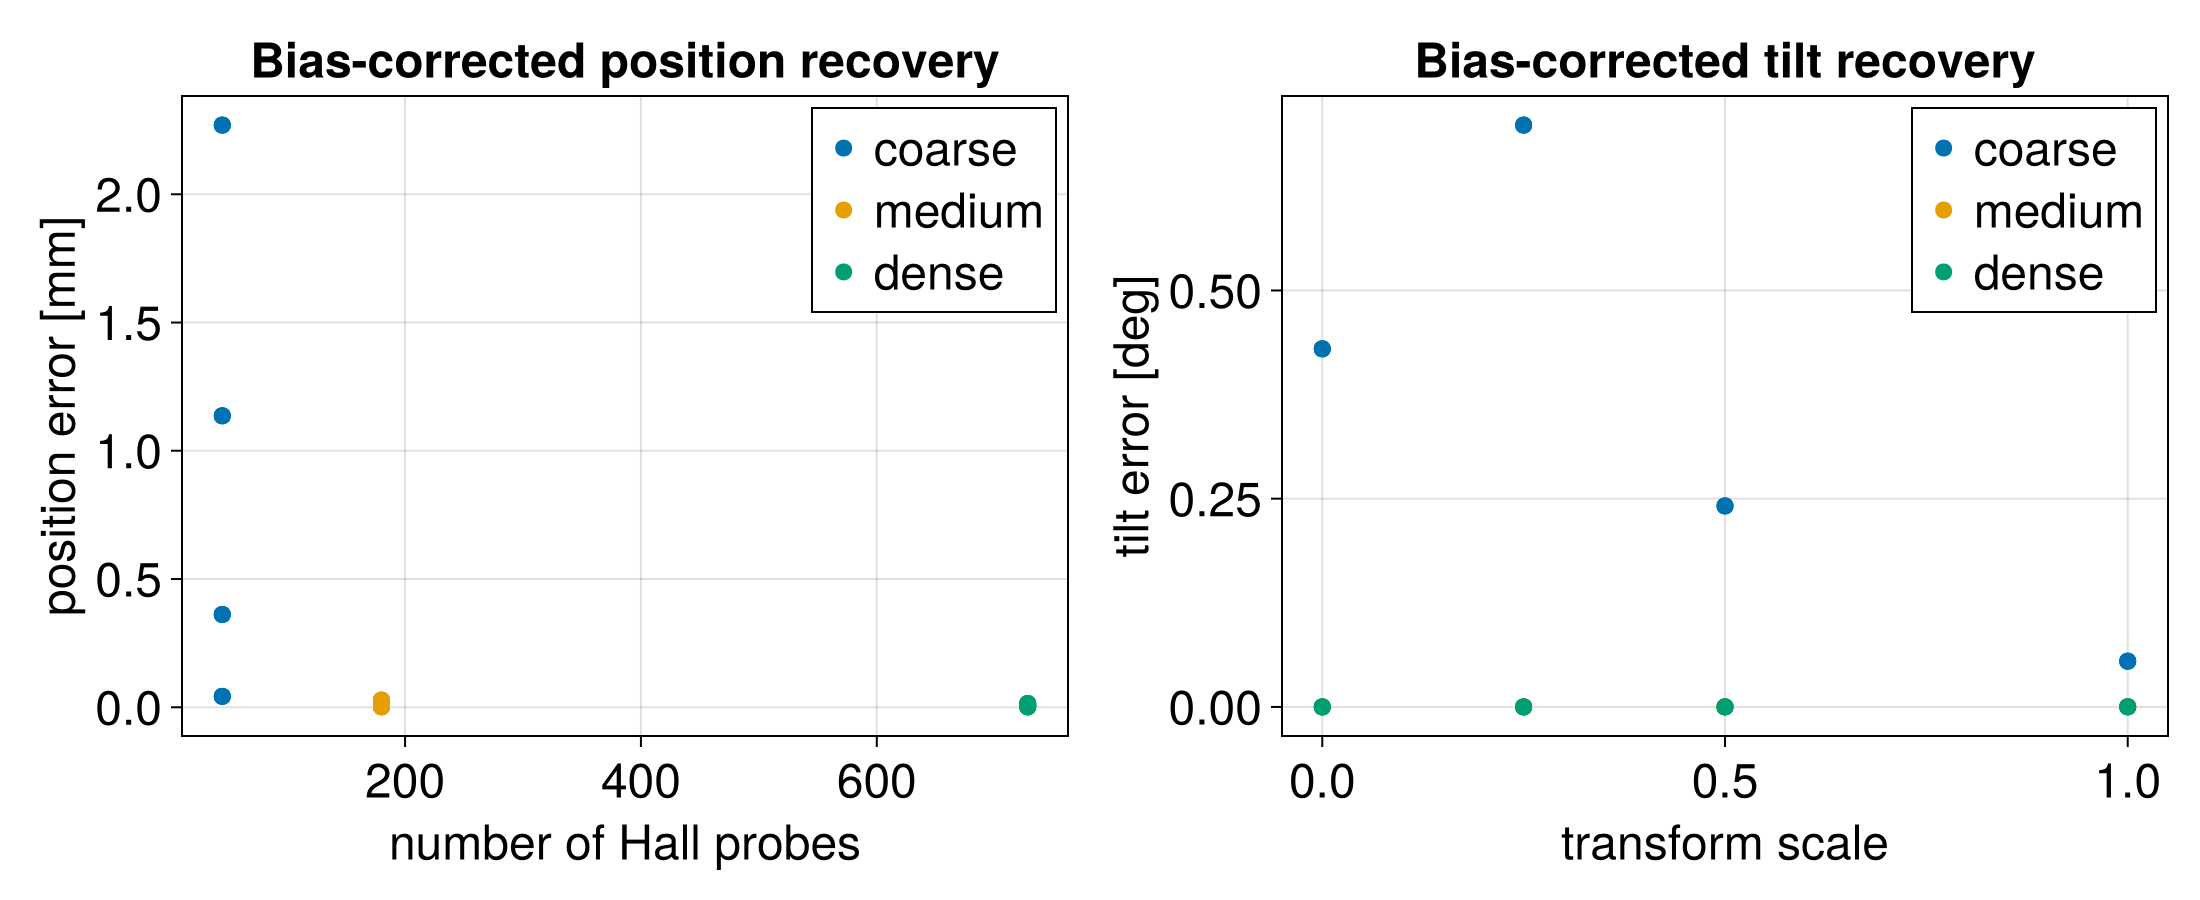

In [ ]:
fig = Figure(size=(1100, 450))

ax1 = Axis(fig[1,1], xlabel="number of Hall probes", ylabel="position error [mm]", title="Bias-corrected position recovery")
for layout in unique(df.layout)
    sub = df[df.layout .== layout, :]
    scatter!(ax1, sub.nprobes, sub.corr_pos_err_mm; label=layout, markersize=12)
end
axislegend(ax1, position=:rt)

ax2 = Axis(fig[1,2], xlabel="transform scale", ylabel="tilt error [deg]", title="Bias-corrected tilt recovery")
for layout in unique(df.layout)
    sub = df[df.layout .== layout, :]
    scatter!(ax2, sub.scale, sub.corr_tilt_err_deg; label=layout, markersize=12)
end
axislegend(ax2, position=:rt)

fig

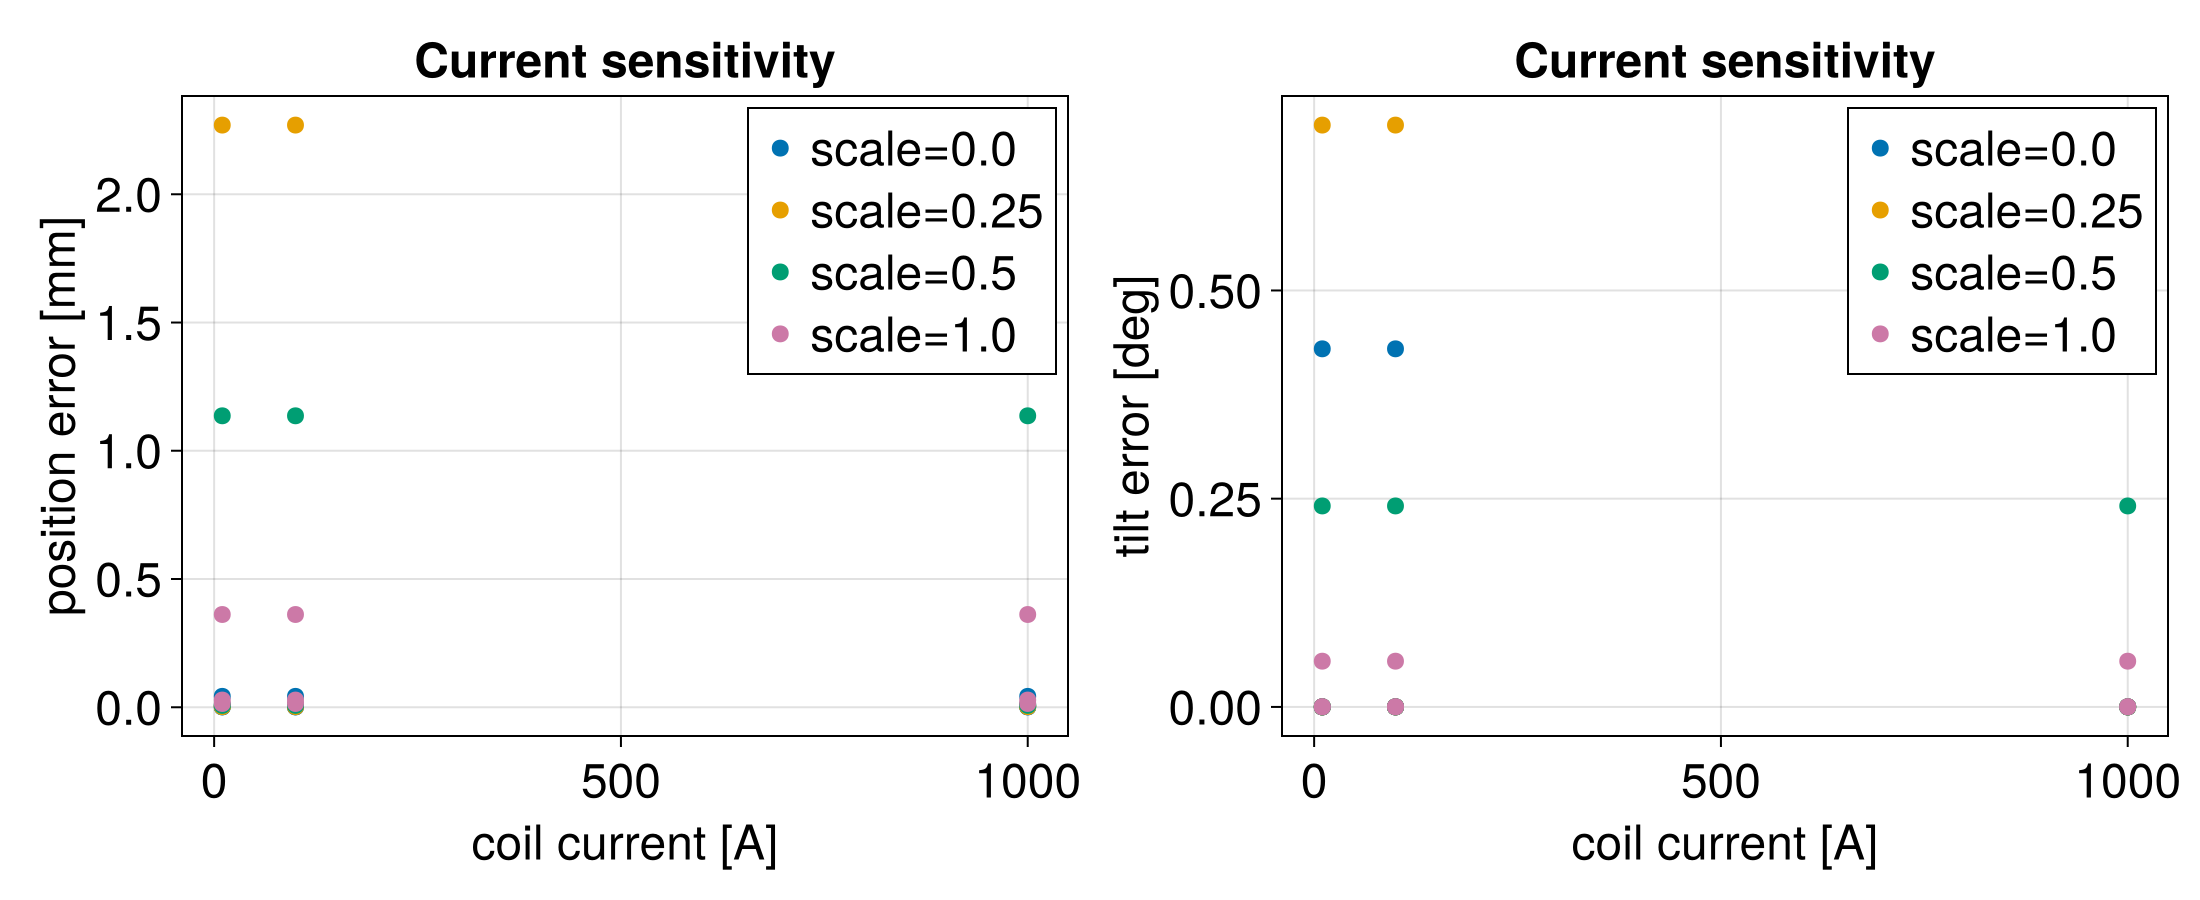

In [ ]:
fig2 = Figure(size=(1100, 450))

ax1 = Axis(fig2[1,1], xlabel="coil current [A]", ylabel="position error [mm]", title="Current sensitivity")
for scale in unique(df.scale)
    sub = df[df.scale .== scale, :]
    scatter!(ax1, sub.current_A, sub.corr_pos_err_mm; label="scale=$(scale)", markersize=12)
end
axislegend(ax1, position=:rt)

ax2 = Axis(fig2[1,2], xlabel="coil current [A]", ylabel="tilt error [deg]", title="Current sensitivity")
for scale in unique(df.scale)
    sub = df[df.scale .== scale, :]
    scatter!(ax2, sub.current_A, sub.corr_tilt_err_deg; label="scale=$(scale)", markersize=12)
end
axislegend(ax2, position=:rt)

fig2

## One-line interpretation helper

`corr_*` columns compare the bias-corrected magnetic-axis estimate to the actual geometric axis of the transformed field coil. These are the main recovery errors.

`raw_*` columns compare the uncorrected sinusoid/local magnetic-axis estimate to the actual transformed field-coil geometry.

Measurement-count layouts:
  N0018   nprobes=  18  inner=(5 phi x 2 z)  outer=(4 phi x 2 z)
  N0023   nprobes=  23  inner=(5 phi x 3 z)  outer=(4 phi x 2 z)
  N0026   nprobes=  26  inner=(6 phi x 3 z)  outer=(4 phi x 2 z)
  N0029   nprobes=  29  inner=(7 phi x 3 z)  outer=(4 phi x 2 z)
  N0047   nprobes=  47  inner=(8 phi x 4 z)  outer=(5 phi x 3 z)
  N0054   nprobes=  54  inner=(9 phi x 4 z)  outer=(6 phi x 3 z)
  N0074   nprobes=  74  inner=(10 phi x 5 z)  outer=(6 phi x 4 z)
  N0094   nprobes=  94  inner=(11 phi x 6 z)  outer=(7 phi x 4 z)
  N0104   nprobes= 104  inner=(12 phi x 6 z)  outer=(8 phi x 4 z)
  N0143   nprobes= 143  inner=(14 phi x 7 z)  outer=(9 phi x 5 z)
  N0188   nprobes= 188  inner=(16 phi x 8 z)  outer=(10 phi x 6 z)
  N0234   nprobes= 234  inner=(18 phi x 9 z)  outer=(12 phi x 6 z)
  N0291   nprobes= 291  inner=(20 phi x 10 z)  outer=(13 phi x 7 z)
  N0396   nprobes= 396  inner=(23 phi x 12 z)  outer=(15 phi x 8 z)
  N0491   nprobes= 491  inner=(26 phi x 13 z)  ou

Row,nprobes,mean_pos_err_mm,max_pos_err_mm,mean_tilt_err_deg,max_tilt_err_deg,nruns
,Int64,Float64,Float64,Float64,Float64,Int64
1,18,136.199,300.599,0.399292,1.19282,4
2,23,1.62283,5.85002,0.103918,0.194924,4
3,26,2.42474,9.04926,0.113298,0.193694,4
4,29,2.76051,9.95205,0.10488,0.191758,4
5,47,0.348457,0.616909,0.144359,0.212569,4
6,54,0.314414,0.605177,0.121677,0.210107,4
7,74,0.0419703,0.146485,0.000669085,0.00152335,4
8,94,0.0612653,0.123859,0.000360954,0.000922205,4
9,104,0.0568146,0.117857,0.000311636,0.00088295,4


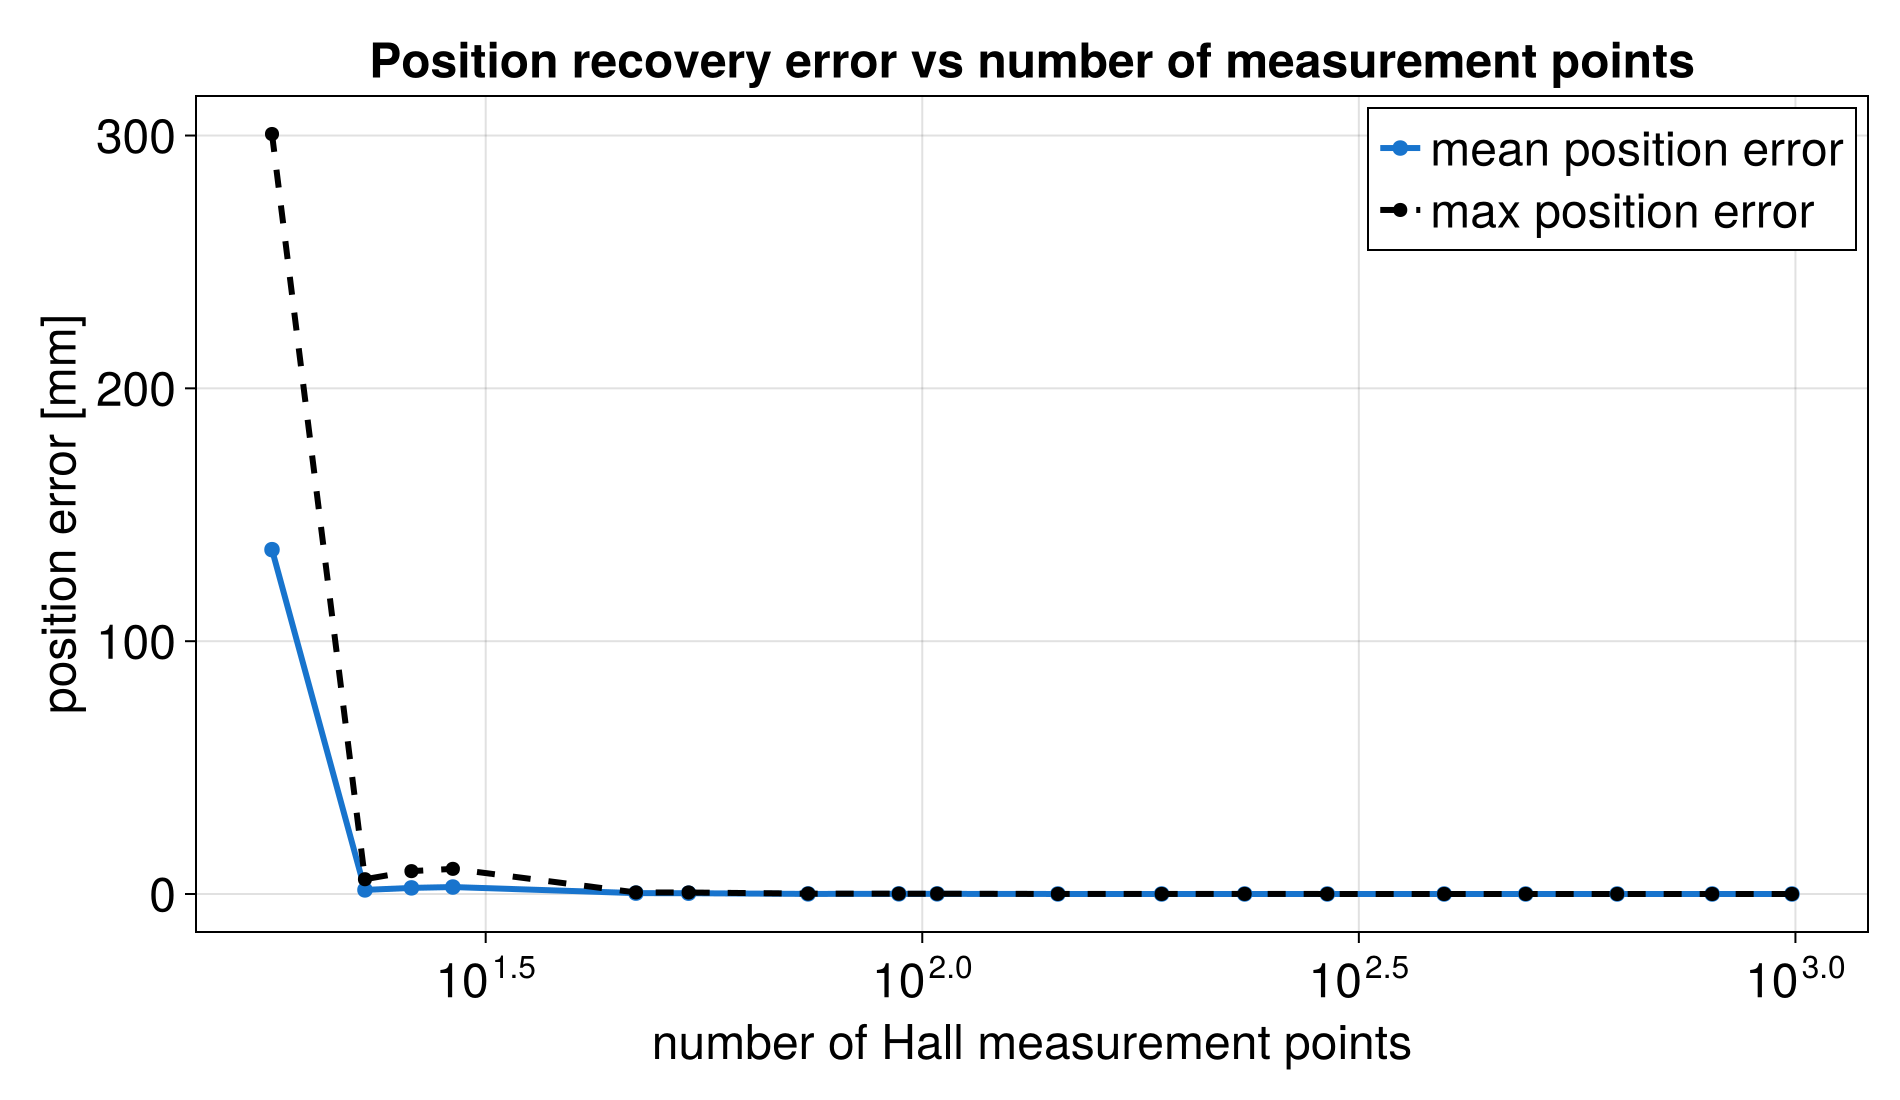

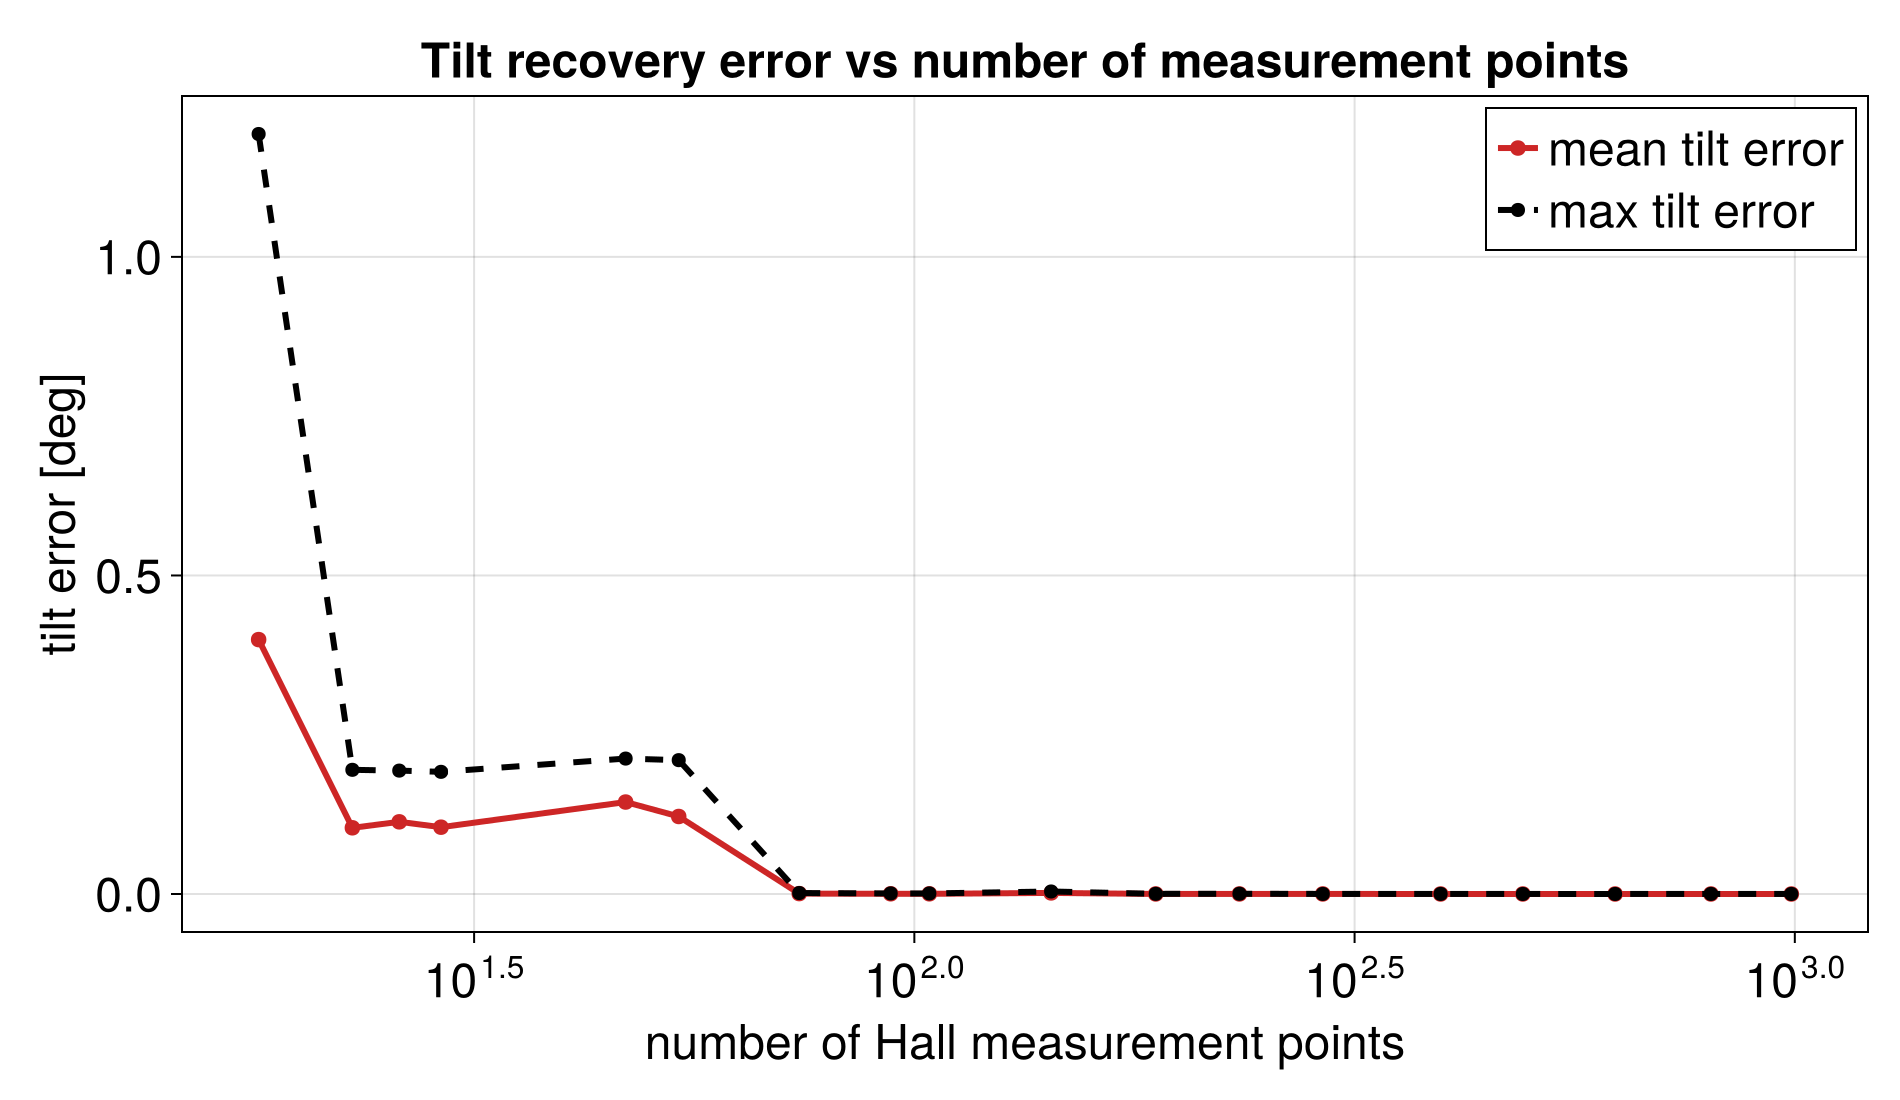

(df_nprobe = 72×29 DataFrame
 Row │ scale    layout  nprobes  current_A  input_shift_x_mm  input_shift_y_mm ⋯
     │ Float64  String  Int64    Float64    Float64           Float64          ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │    0.0   N0018        18      100.0               0.0               0.0 ⋯
   2 │    0.25  N0018        18      100.0               2.5               7.5
   3 │    0.5   N0018        18      100.0               5.0              15.0
   4 │    1.0   N0018        18      100.0              10.0              30.0
   5 │    0.0   N0023        23      100.0               0.0               0.0 ⋯
   6 │    0.25  N0023        23      100.0               2.5               7.5
   7 │    0.5   N0023        23      100.0               5.0              15.0
   8 │    1.0   N0023        23      100.0              10.0              30.0
  ⋮  │    ⋮       ⋮        ⋮         ⋮             ⋮                 ⋮         ⋱
  66 │    0

In [ ]:
begin
    using CairoMakie
    using DataFrames
    using Statistics
    using Printf

    # ------------------------------------------------------------
    # Measurement-count scan configuration
    # ------------------------------------------------------------

    # The algorithm needs enough phi/z points to fit the sinusoid.
    # With two shells, the practical minimum is about:
    # inner: nphi >= 4, nz >= 2
    # outer: nphi >= 4, nz >= 2
    # so the lowest useful total is roughly 16 probes.
    NPROBE_TARGETS = round.(Int, exp10.(range(log10(16), log10(1000), length=18)))

    # Use one current unless you also want to study noise/current sensitivity.
    # If B_NOISE_ABS_T = 0 and B_NOISE_REL = 0, current mostly should not matter.
    NPROBE_SCAN_CURRENT_A = 100.0

    # These provide multiple cases per measurement count, so mean/max are meaningful.
    # You can reduce this to [1.0] for speed, or use transform_scales for consistency.
    NPROBE_SCAN_SCALES = transform_scales

    # Repeats are only useful if you have synthetic noise turned on.
    # If noise is zero, repeated seeds give identical fields.
    NPROBE_SCAN_REPEATS = (B_NOISE_ABS_T > 0 || B_NOISE_REL > 0) ? 3 : 1

    # ------------------------------------------------------------
    # Build approximate layouts for requested total measurement counts
    # ------------------------------------------------------------

    function make_layout_for_target_nprobes(target_N::Int)
        # Split probes between inner and outer shells.
        # Inner gets more because it usually has the wider z-span.
        Ni_target = max(8, round(Int, 0.70 * target_N))
        No_target = max(8, target_N - Ni_target)

        # Choose roughly sqrt-like nphi/nz dimensions.
        # More phi than z is usually helpful for sinusoidal tilt fitting.
        nphi_i = max(4, round(Int, sqrt(2.0 * Ni_target)))
        nz_i   = max(2, round(Int, Ni_target / nphi_i))

        nphi_o = max(4, round(Int, sqrt(2.0 * No_target)))
        nz_o   = max(2, round(Int, No_target / nphi_o))

        actual_N = nphi_i * nz_i + nphi_o * nz_o

        return (
            name = @sprintf("N%04d", actual_N),
            nphi_i = nphi_i,
            nz_i = nz_i,
            nphi_o = nphi_o,
            nz_o = nz_o,
        )
    end

    measurement_layouts = NamedTuple[]
    seen_nprobes = Set{Int}()

    for Ntarg in NPROBE_TARGETS
        layout = make_layout_for_target_nprobes(Ntarg)
        actual_N = layout.nphi_i * layout.nz_i + layout.nphi_o * layout.nz_o

        if !(actual_N in seen_nprobes)
            push!(measurement_layouts, layout)
            push!(seen_nprobes, actual_N)
        end
    end

    println("Measurement-count layouts:")
    for layout in measurement_layouts
        actual_N = layout.nphi_i * layout.nz_i + layout.nphi_o * layout.nz_o
        @printf(
            "  %-6s  nprobes=%4d  inner=(%d phi x %d z)  outer=(%d phi x %d z)\n",
            layout.name,
            actual_N,
            layout.nphi_i,
            layout.nz_i,
            layout.nphi_o,
            layout.nz_o,
        )
    end

    # ------------------------------------------------------------
    # Run scan
    # ------------------------------------------------------------

    rows_nprobe = NamedTuple[]

    total_nprobe_cases =
        length(measurement_layouts) *
        length(NPROBE_SCAN_SCALES) *
        NPROBE_SCAN_REPEATS

    case_idx_nprobe = 0

    for layout in measurement_layouts
        for scale in NPROBE_SCAN_SCALES
            for rep in 1:NPROBE_SCAN_REPEATS
                global case_idx_nprobe += 1

                @printf(
                    "[%d/%d] nprobes=%d layout=%s scale=%.2f I=%.1f A repeat=%d\n",
                    case_idx_nprobe,
                    total_nprobe_cases,
                    layout.nphi_i * layout.nz_i + layout.nphi_o * layout.nz_o,
                    layout.name,
                    scale,
                    NPROBE_SCAN_CURRENT_A,
                    rep,
                )

                try
                    push!(
                        rows_nprobe,
                        analyze_one_case(
                            scale = scale,
                            layout = layout,
                            current_A = NPROBE_SCAN_CURRENT_A,
                            seed = RNG_SEED + 10_000 + case_idx_nprobe,
                        ),
                    )
                catch err
                    @warn "nprobe scan case failed" layout=layout.name scale rep exception=(err, catch_backtrace())
                end
            end
        end
    end

    df_nprobe = DataFrame(rows_nprobe)

    csv_nprobe_path = joinpath(SCAN_OUTPUT_DIR, "coil_centering_nprobe_scan_results.csv")
    CSV.write(csv_nprobe_path, df_nprobe)
    println("Saved: ", csv_nprobe_path)

    # ------------------------------------------------------------
    # Aggregate by number of measurement points
    # ------------------------------------------------------------

    plot_df = df_nprobe[
        isfinite.(df_nprobe.nprobes) .&
        isfinite.(df_nprobe.corr_pos_err_mm) .&
        isfinite.(df_nprobe.corr_tilt_err_deg),
        :
    ]

    g_nprobe = combine(
        groupby(plot_df, :nprobes),
        :corr_pos_err_mm => mean    => :mean_pos_err_mm,
        :corr_pos_err_mm => maximum => :max_pos_err_mm,
        :corr_tilt_err_deg => mean    => :mean_tilt_err_deg,
        :corr_tilt_err_deg => maximum => :max_tilt_err_deg,
        nrow => :nruns,
    )

    sort!(g_nprobe, :nprobes)

    display(g_nprobe)

    # ------------------------------------------------------------
    # Plot 1: position error vs number of measurement points
    # ------------------------------------------------------------

    fig_pos = Figure(size=(950, 550))

    ax_pos = Axis(
        fig_pos[1, 1],
        xlabel = "number of Hall measurement points",
        ylabel = "position error [mm]",
        title = "Position recovery error vs number of measurement points",
        xscale = log10,
    )

    scatterlines!(
        ax_pos,
        g_nprobe.nprobes,
        g_nprobe.mean_pos_err_mm;
        color = :dodgerblue3,
        markercolor = :dodgerblue3,
        markersize = 11,
        linewidth = 3,
        label = "mean position error",
    )

    scatterlines!(
        ax_pos,
        g_nprobe.nprobes,
        g_nprobe.max_pos_err_mm;
        color = :black,
        markercolor = :black,
        markersize = 10,
        linewidth = 3,
        linestyle = :dash,
        label = "max position error",
    )

    axislegend(ax_pos, position = :rt)

    # ------------------------------------------------------------
    # Plot 2: tilt error vs number of measurement points
    # ------------------------------------------------------------

    fig_tilt = Figure(size=(950, 550))

    ax_tilt = Axis(
        fig_tilt[1, 1],
        xlabel = "number of Hall measurement points",
        ylabel = "tilt error [deg]",
        title = "Tilt recovery error vs number of measurement points",
        xscale = log10,
    )

    scatterlines!(
        ax_tilt,
        g_nprobe.nprobes,
        g_nprobe.mean_tilt_err_deg;
        color = :firebrick3,
        markercolor = :firebrick3,
        markersize = 11,
        linewidth = 3,
        label = "mean tilt error",
    )

    scatterlines!(
        ax_tilt,
        g_nprobe.nprobes,
        g_nprobe.max_tilt_err_deg;
        color = :black,
        markercolor = :black,
        markersize = 10,
        linewidth = 3,
        linestyle = :dash,
        label = "max tilt error",
    )

    axislegend(ax_tilt, position = :rt)

    display(fig_pos)
    display(fig_tilt)

    (; df_nprobe, g_nprobe, fig_pos, fig_tilt)
end

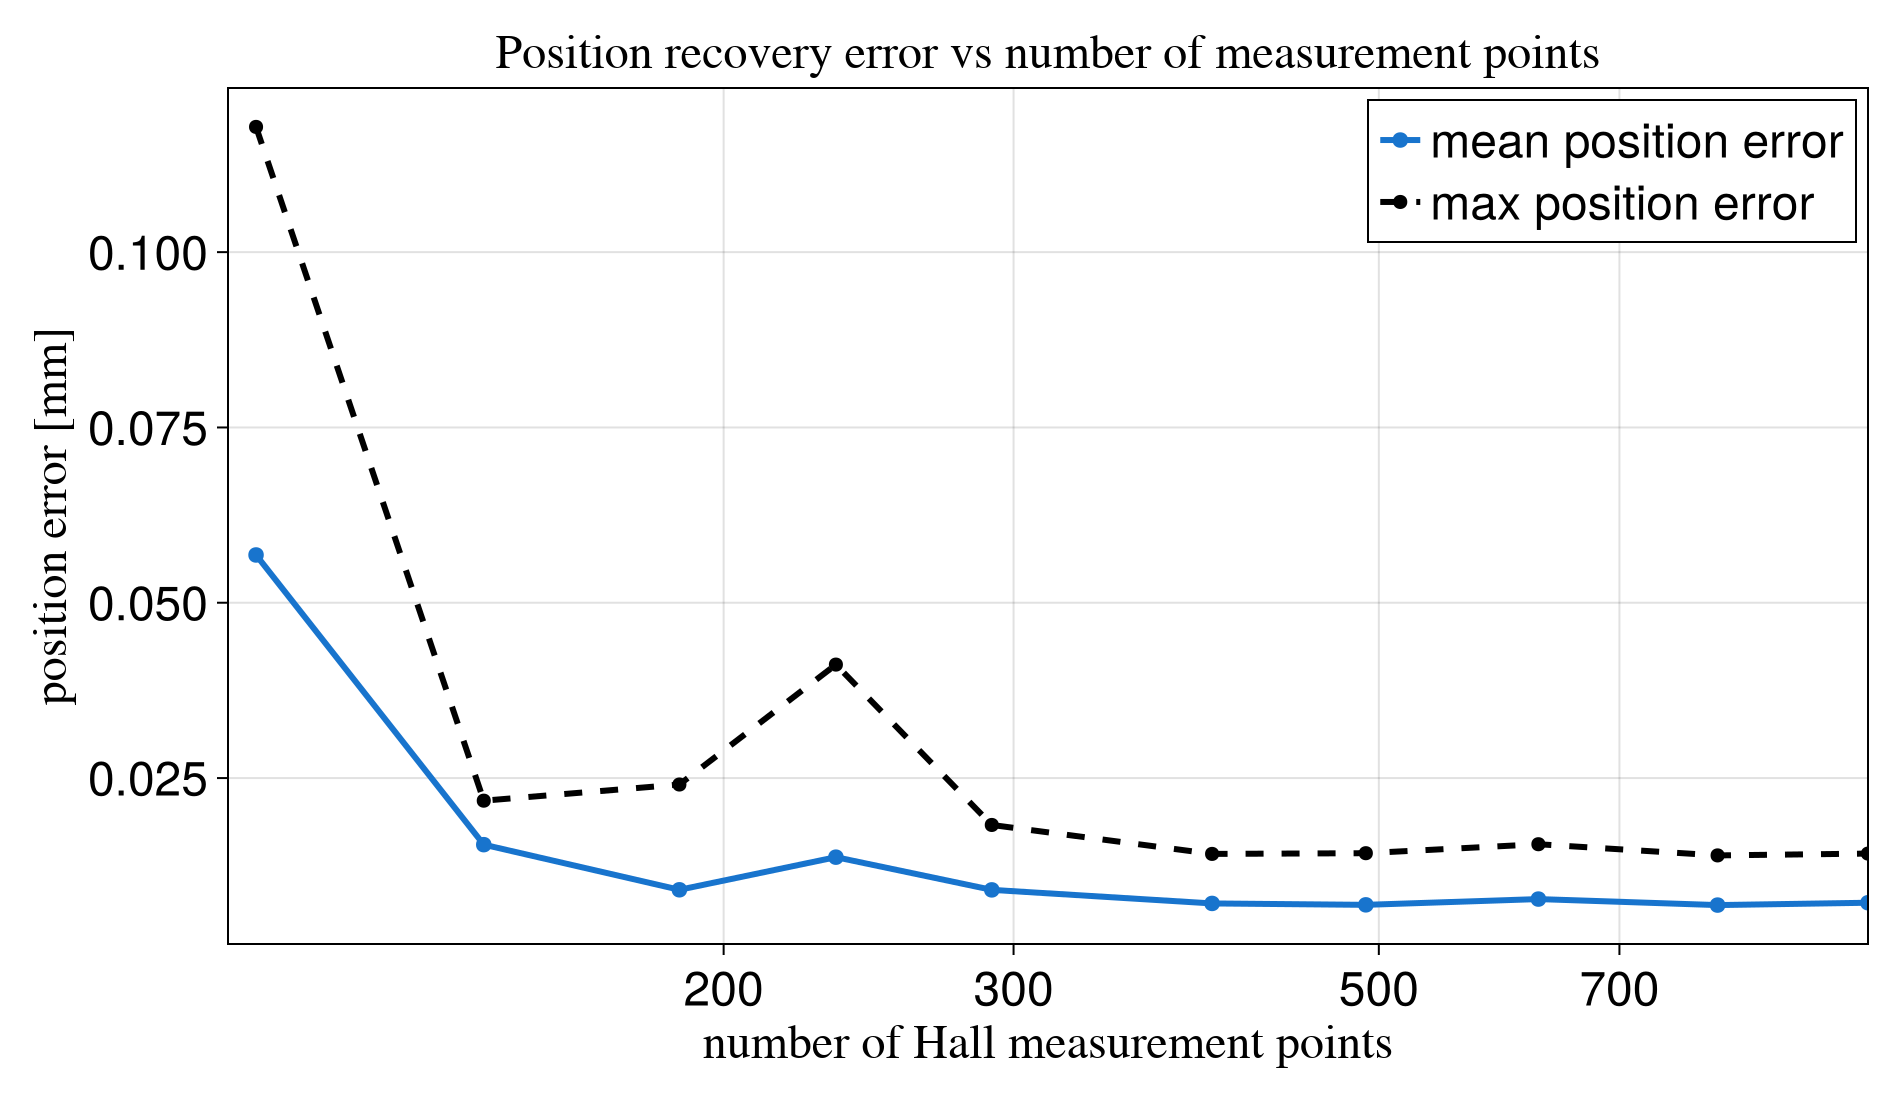

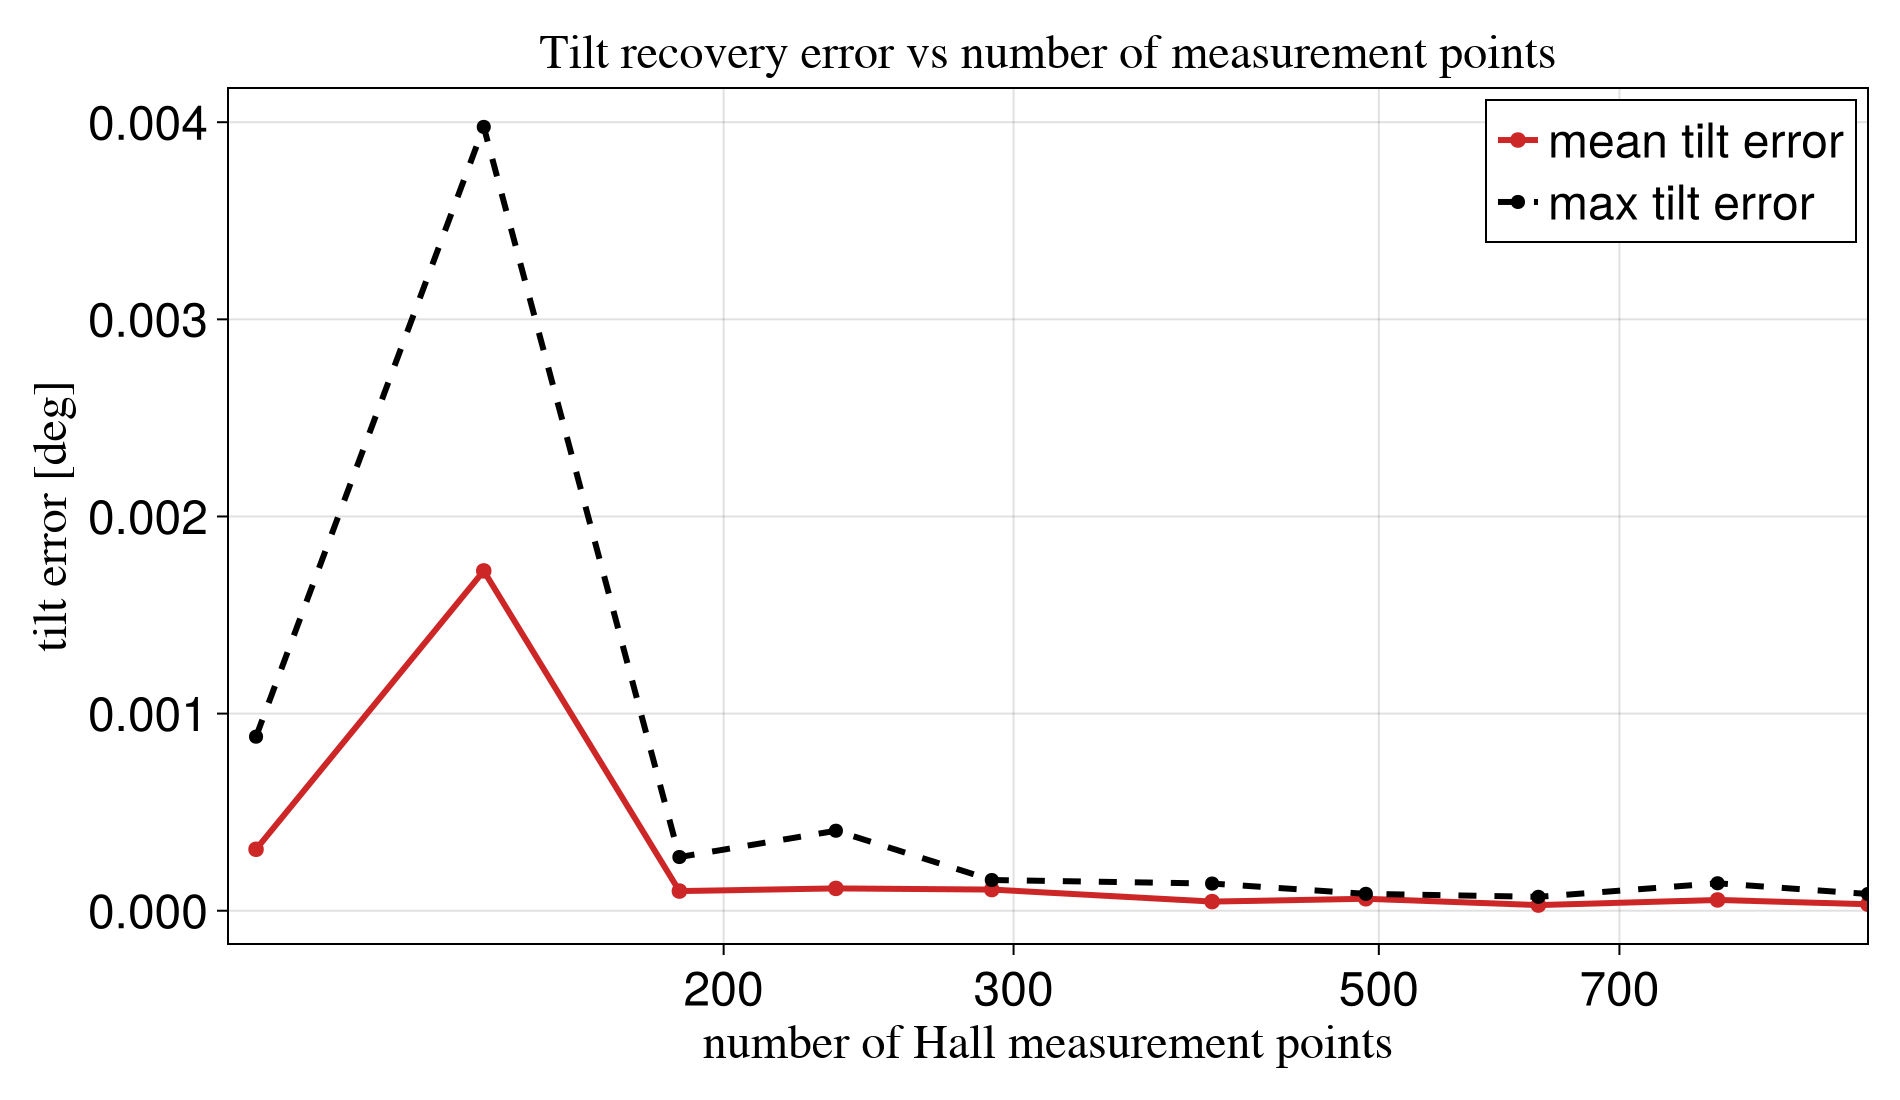

(fig_pos_100 = Scene(2 children, 0 plots), fig_tilt_100 = Scene(2 children, 0 plots))

In [ ]:
begin
    using CairoMakie

    set_theme!(Theme(
        font = "Times",
        fontsize = 24,
        Axis = (
            titlefont = "Times",
            xlabelfont = "Times",
            ylabelfont = "Times",
            tickfont = "Times",
            legendfont = "Times",
        )
    ))

    # Keep only points with nprobes >= 100
    gplot = g_nprobe[g_nprobe.nprobes .>= 100, :]

    xticks = [100, 200, 300, 500, 700, 1000]
    xticks = xticks[
        (xticks .>= minimum(gplot.nprobes)) .&
        (xticks .<= maximum(gplot.nprobes))
    ]

    xtick_labels = string.(xticks)

    fig_pos_100 = Figure(size=(950, 550))

    ax_pos_100 = Axis(
        fig_pos_100[1, 1],
        xlabel = "number of Hall measurement points",
        ylabel = "position error [mm]",
        title = "Position recovery error vs number of measurement points",
        xscale = log10,
        limits = ((100, maximum(gplot.nprobes)), nothing),
        xticks = (xticks, xtick_labels),
    )

    scatterlines!(ax_pos_100, gplot.nprobes, gplot.mean_pos_err_mm;
        color = :dodgerblue3, markercolor = :dodgerblue3,
        markersize = 11, linewidth = 3, label = "mean position error")

    scatterlines!(ax_pos_100, gplot.nprobes, gplot.max_pos_err_mm;
        color = :black, markercolor = :black,
        markersize = 10, linewidth = 3,
        linestyle = :dash, label = "max position error")

    axislegend(ax_pos_100, position = :rt)

    fig_tilt_100 = Figure(size=(950, 550))

    ax_tilt_100 = Axis(
        fig_tilt_100[1, 1],
        xlabel = "number of Hall measurement points",
        ylabel = "tilt error [deg]",
        title = "Tilt recovery error vs number of measurement points",
        xscale = log10,
        limits = ((100, maximum(gplot.nprobes)), nothing),
        xticks = (xticks, xtick_labels),
    )

    scatterlines!(ax_tilt_100, gplot.nprobes, gplot.mean_tilt_err_deg;
        color = :firebrick3, markercolor = :firebrick3,
        markersize = 11, linewidth = 3, label = "mean tilt error")

    scatterlines!(ax_tilt_100, gplot.nprobes, gplot.max_tilt_err_deg;
        color = :black, markercolor = :black,
        markersize = 10, linewidth = 3,
        linestyle = :dash, label = "max tilt error")

    axislegend(ax_tilt_100, position = :rt)

    display(fig_pos_100)
    display(fig_tilt_100)

    (; fig_pos_100, fig_tilt_100)
end

[1/108] shift_only scale=0.000 layout=coarse nprobes=45 I=100.0 A repeat=1
[2/108] shift_only scale=0.000 layout=medium nprobes=180 I=100.0 A repeat=1
[3/108] shift_only scale=0.000 layout=dense nprobes=728 I=100.0 A repeat=1
[4/108] shift_only scale=0.059 layout=coarse nprobes=45 I=100.0 A repeat=1
[5/108] shift_only scale=0.059 layout=medium nprobes=180 I=100.0 A repeat=1
[6/108] shift_only scale=0.059 layout=dense nprobes=728 I=100.0 A repeat=1
[7/108] shift_only scale=0.118 layout=coarse nprobes=45 I=100.0 A repeat=1
[8/108] shift_only scale=0.118 layout=medium nprobes=180 I=100.0 A repeat=1
[9/108] shift_only scale=0.118 layout=dense nprobes=728 I=100.0 A repeat=1
[10/108] shift_only scale=0.176 layout=coarse nprobes=45 I=100.0 A repeat=1
[11/108] shift_only scale=0.176 layout=medium nprobes=180 I=100.0 A repeat=1
[12/108] shift_only scale=0.176 layout=dense nprobes=728 I=100.0 A repeat=1
[13/108] shift_only scale=0.235 layout=coarse nprobes=45 I=100.0 A repeat=1
[14/108] shift_on

Row,input_shift_mag_mm,mean_pos_err_mm,max_pos_err_mm,mean_tilt_err_deg,max_tilt_err_deg,nruns
,Float64,Float64,Float64,Float64,Float64,Int64
1,0.0,0.0152382,0.0425453,0.143311,0.429932,3
2,3.48005,0.0247603,0.0697387,0.113598,0.340791,3
3,6.96009,0.0186845,0.0501472,0.0779254,0.233773,3
4,10.4401,0.0101017,0.0231541,0.0525253,0.157572,3
5,13.9202,0.00555115,0.00844903,0.0350871,0.105257,3
6,17.4002,0.00500678,0.00754481,0.0234905,0.0704657,3
7,20.8803,0.00453529,0.00812483,0.0159481,0.0478369,3
8,24.3603,0.0045074,0.00842454,0.0110658,0.0331882,3
9,27.8404,0.00396455,0.00842692,0.00784271,0.0235169,3


Row,input_tilt_mag_deg,mean_pos_err_mm,max_pos_err_mm,mean_tilt_err_deg,max_tilt_err_deg,nruns
,Float64,Float64,Float64,Float64,Float64,Int64
1,0.0,0.0152382,0.0425453,0.143311,0.429932,3
2,0.299942,0.0355019,0.104382,0.28895,0.86685,3
3,0.599885,0.0736976,0.217074,0.375162,1.12548,3
4,0.899827,0.085732,0.250577,0.324311,0.972914,3
5,1.19977,0.0808628,0.233281,0.233296,0.699859,3
6,1.49971,0.0687349,0.194166,0.150158,0.45044,3
7,1.79965,0.0557925,0.152605,0.0882921,0.264831,3
8,2.0996,0.0449314,0.117336,0.0493865,0.147998,3
9,2.39954,0.0372752,0.0918267,0.0305167,0.0913948,3


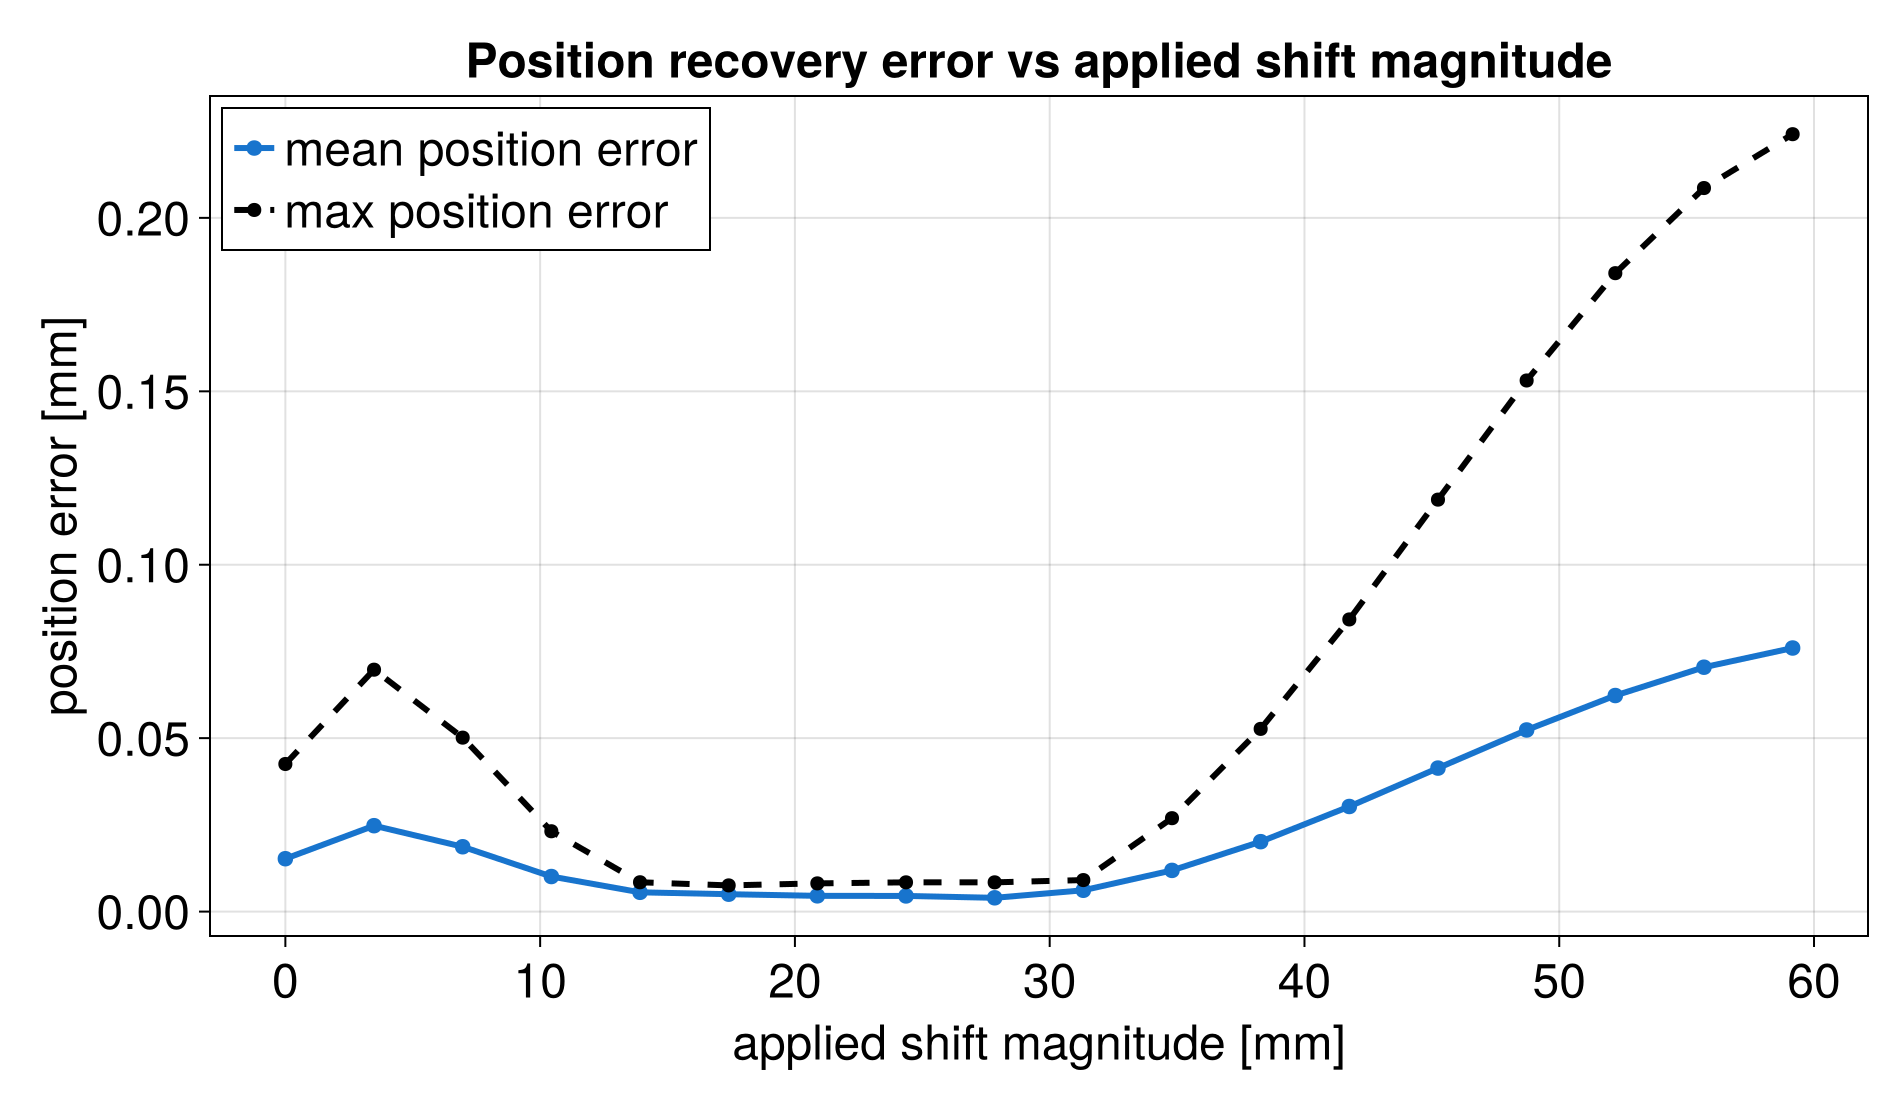

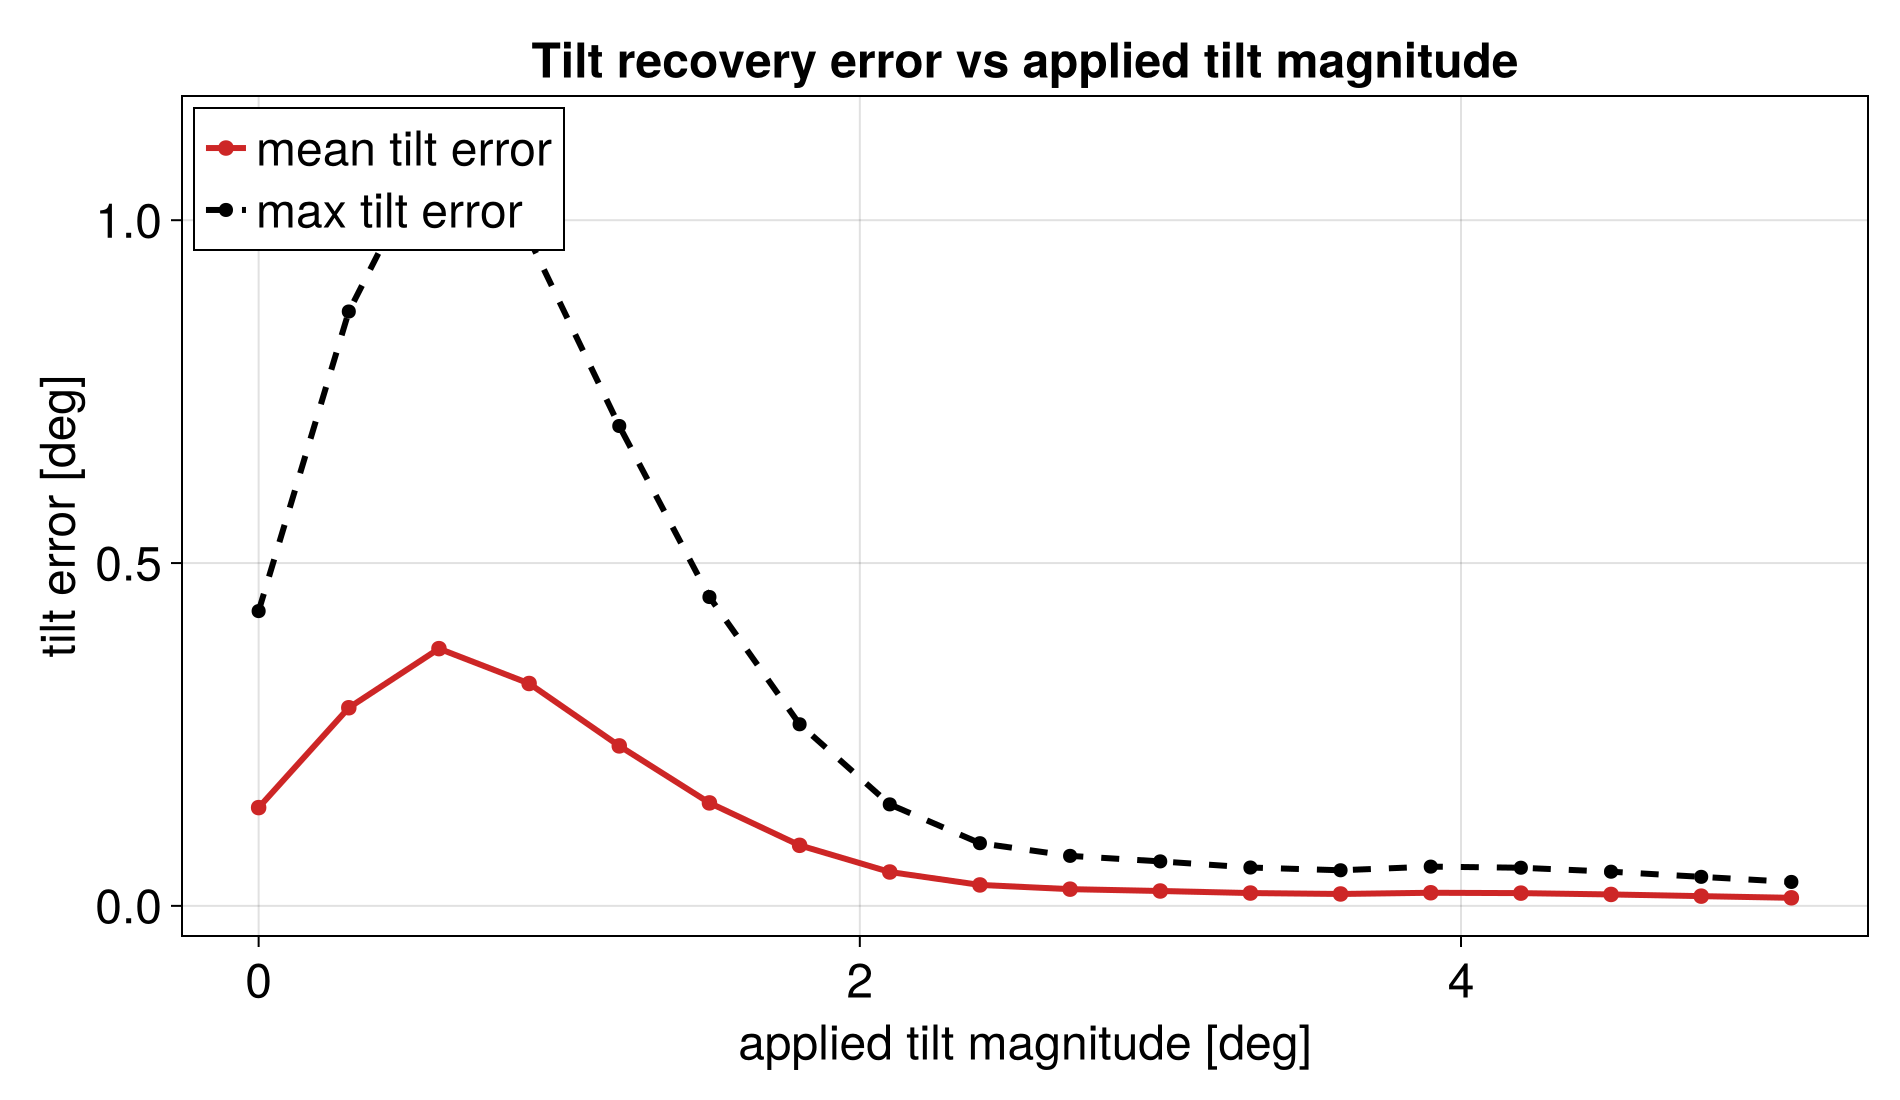

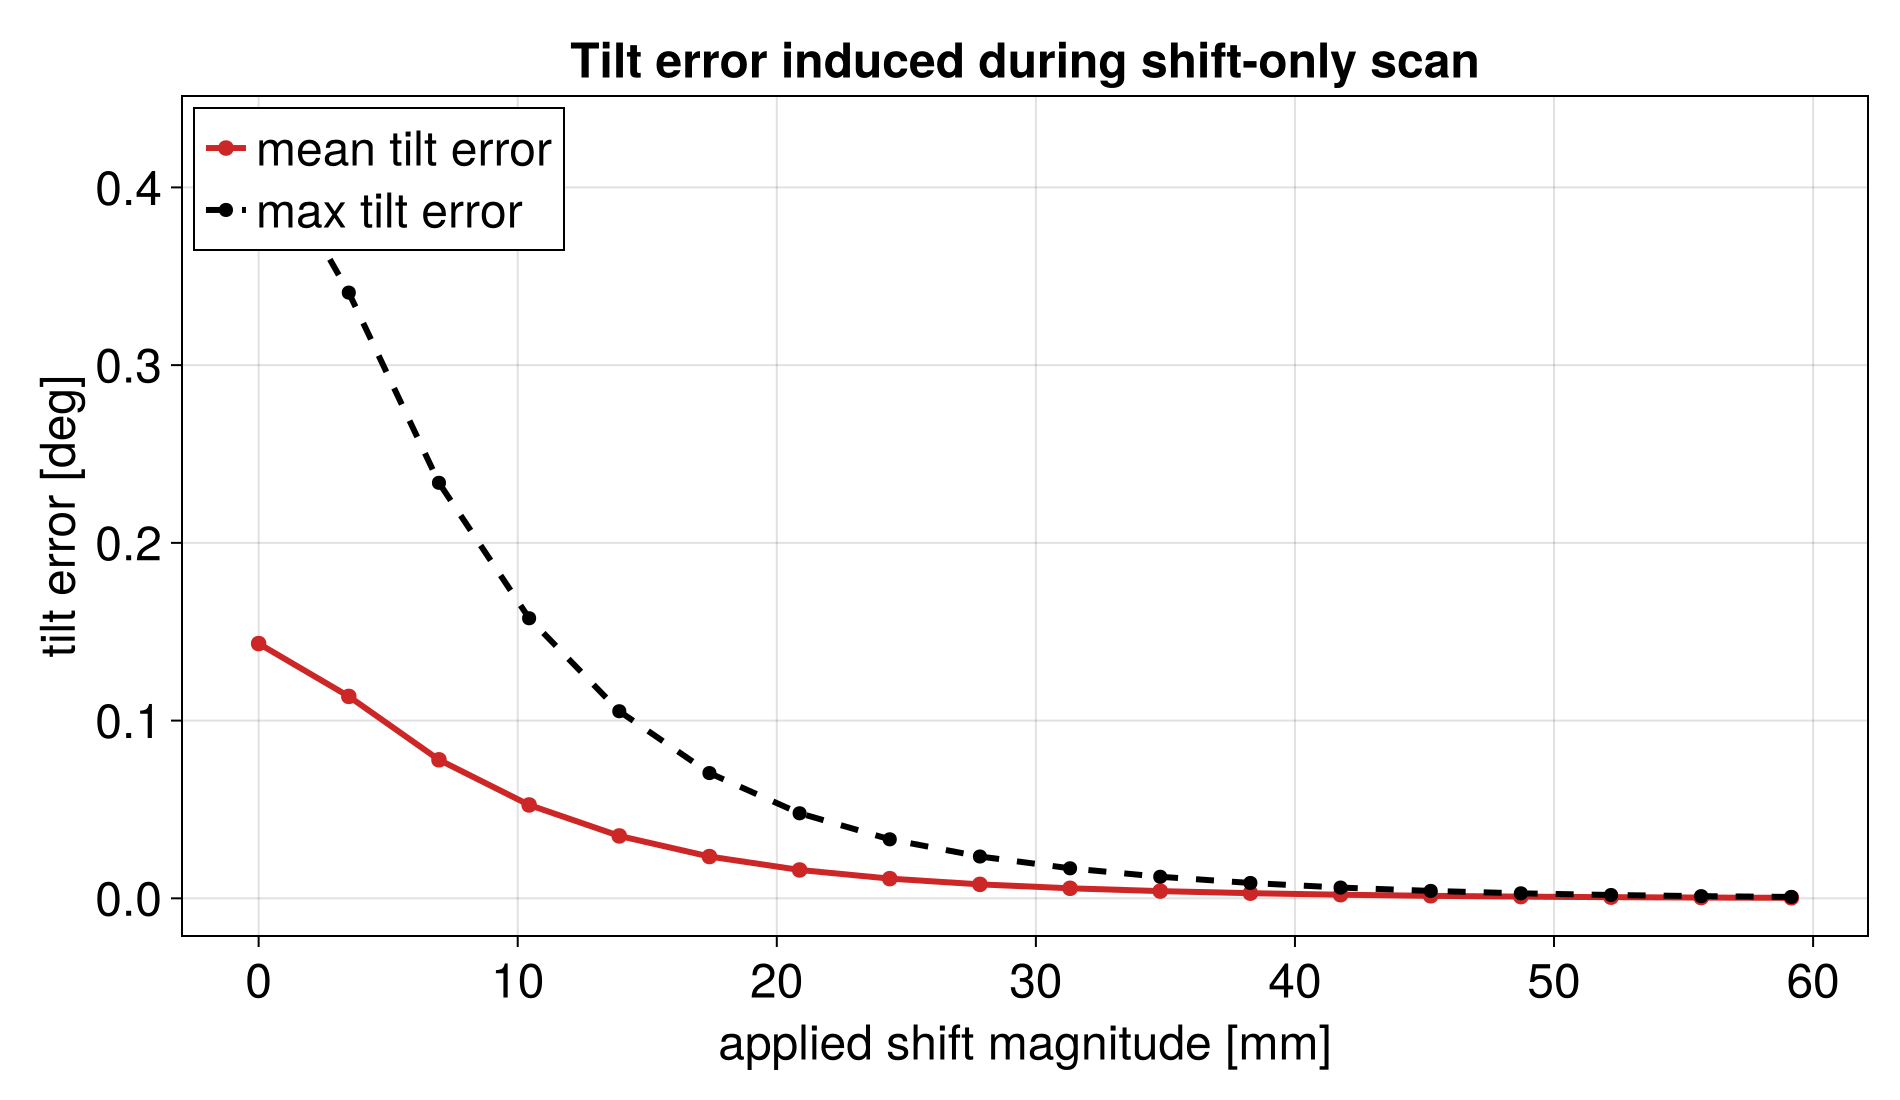

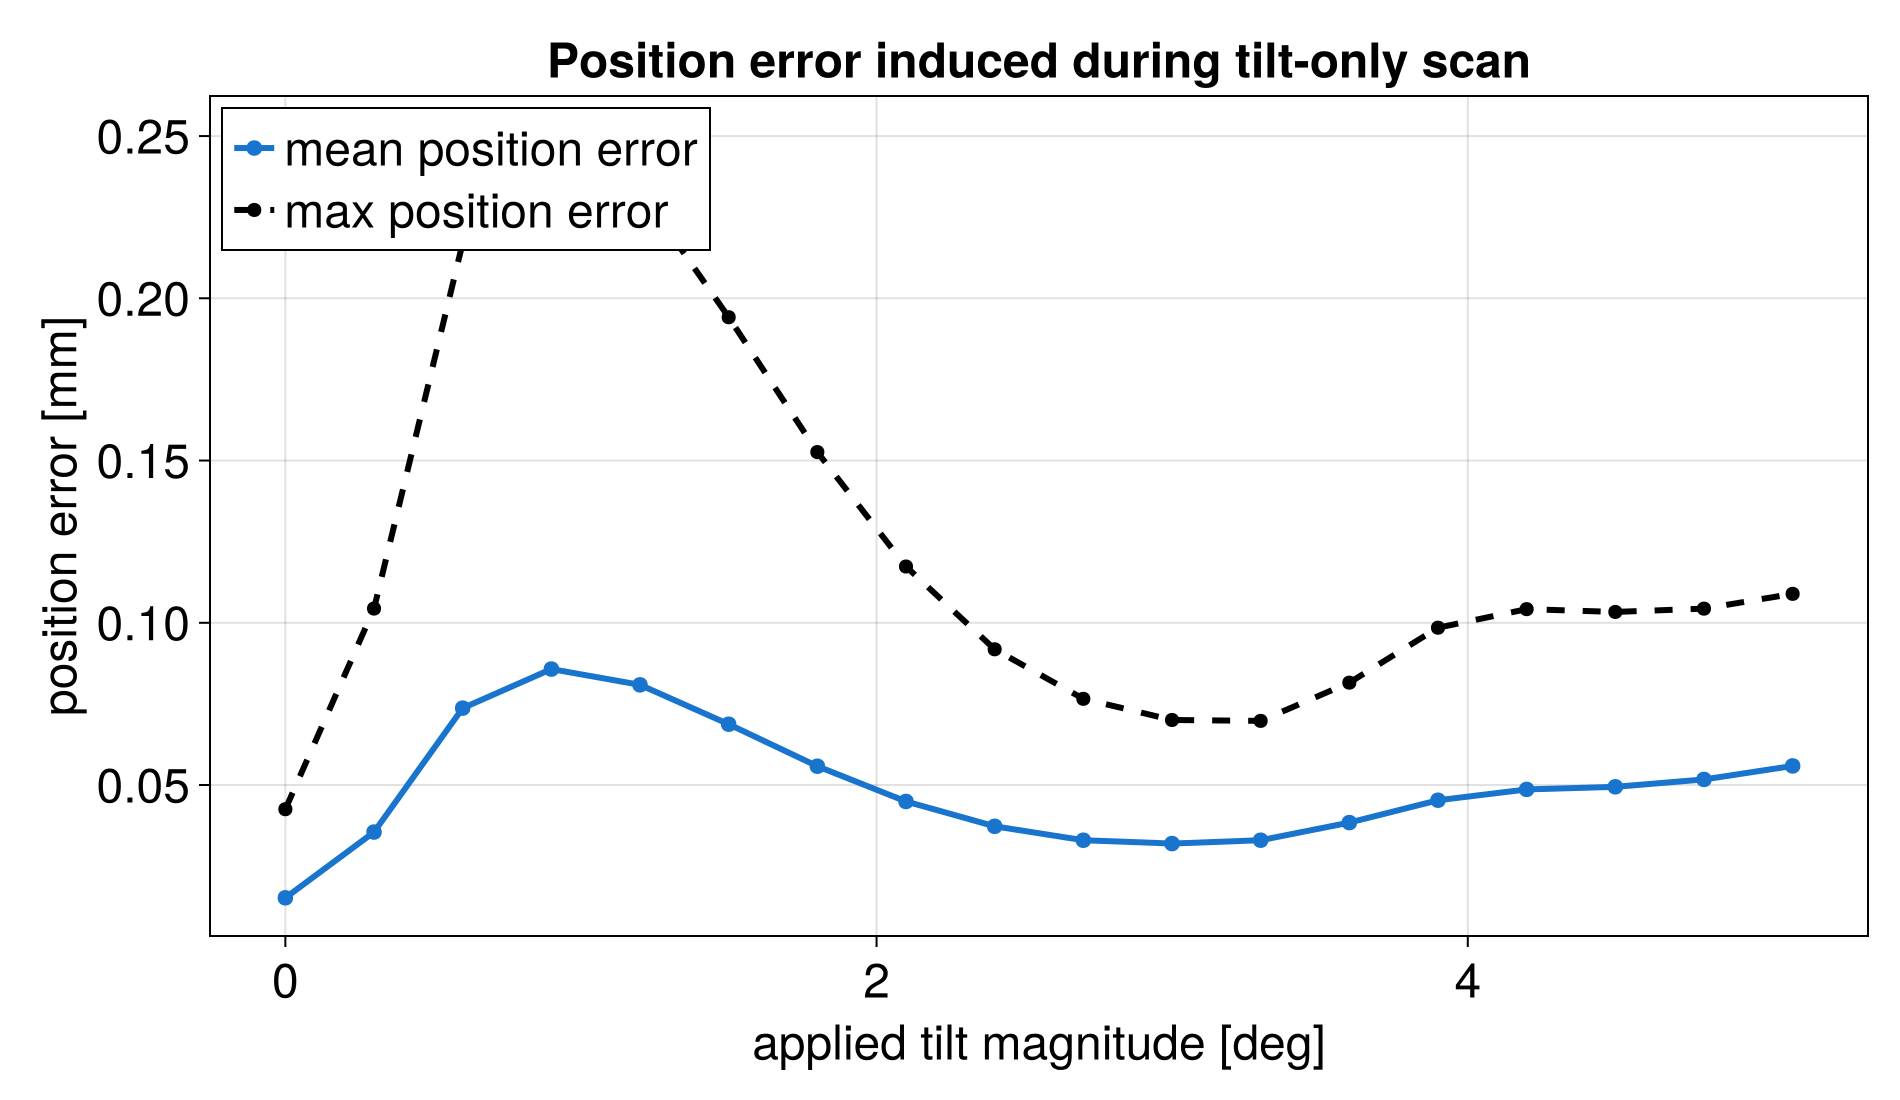

(df_mag = 108×35 DataFrame
 Row │ shift_scale  tilt_scale  layout  nprobes  current_A  input_shift_x_mm   ⋯
     │ Float64      Float64     String  Int64    Float64    Float64            ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │   0.0          0.0       coarse       45      100.0          0.0        ⋯
   2 │   0.0          0.0       medium      180      100.0          0.0
   3 │   0.0          0.0       dense       728      100.0          0.0
   4 │   0.0588235    0.0       coarse       45      100.0          0.588235
   5 │   0.0588235    0.0       medium      180      100.0          0.588235   ⋯
   6 │   0.0588235    0.0       dense       728      100.0          0.588235
   7 │   0.117647     0.0       coarse       45      100.0          1.17647
   8 │   0.117647     0.0       medium      180      100.0          1.17647
  ⋮  │      ⋮           ⋮         ⋮        ⋮         ⋮             ⋮           ⋱
 102 │   0.0          0.882353  dense

In [ ]:
begin
    using CairoMakie
    using DataFrames
    using Statistics
    using Printf

    # ------------------------------------------------------------
    # Shift / tilt magnitude scan configuration
    # ------------------------------------------------------------

    # About 10–20 x-axis points
    MAGNITUDE_SCAN_SCALES = collect(range(0.0, 1.0, length=18))

    # Choose layouts to include in the statistics.
    # For speed, use only dense or medium.
    # For more robust mean/max, use all three.
    MAGNITUDE_SCAN_LAYOUTS = hall_layouts
    # MAGNITUDE_SCAN_LAYOUTS = [hall_layouts[end]]  # dense only

    # Use one current unless studying noise/current dependence.
    MAGNITUDE_SCAN_CURRENT_A = 100.0

    # Repeats only matter if B_NOISE_ABS_T or B_NOISE_REL is nonzero.
    MAGNITUDE_SCAN_REPEATS = (B_NOISE_ABS_T > 0 || B_NOISE_REL > 0) ? 3 : 1

    # ------------------------------------------------------------
    # Custom analyzer allowing independent shift and tilt scaling
    # ------------------------------------------------------------

    function analyze_one_shift_tilt_magnitude_case(;
        shift_scale,
        tilt_scale,
        layout,
        current_A,
        noise_abs_T = B_NOISE_ABS_T,
        noise_rel = B_NOISE_REL,
        seed = RNG_SEED,
    )
        tag = @sprintf(
            "shift_%05.2f_tilt_%05.2f_%s_I_%g",
            shift_scale,
            tilt_scale,
            layout.name,
            current_A,
        )

        field_file = joinpath(
            SCAN_OUTPUT_DIR,
            "field_magnitude_$(replace(tag, '.' => 'p')).dat",
        )

        sx = shift_scale * BASE_SHIFT_X
        sy = shift_scale * BASE_SHIFT_Y
        sz = shift_scale * BASE_SHIFT_Z

        tx = tilt_scale * BASE_TILT_X_DEG
        ty = tilt_scale * BASE_TILT_Y_DEG
        tz = tilt_scale * BASE_TILT_Z_DEG

        transform_coil_file(
            PHYSICAL_COIL_FILE,
            field_file;
            shift_x = sx,
            shift_y = sy,
            shift_z = sz,
            tilt_x_deg = tx,
            tilt_y_deg = ty,
            tilt_z_deg = tz,
        )

        physical_coils = load_coils(PHYSICAL_COIL_FILE; current_A = current_A)
        field_coils    = load_coils(field_file; current_A = current_A)
        model_coils    = load_coils(PHYSICAL_COIL_FILE; current_A = current_A)

        phys_geom  = axis_from_coil(physical_coils)
        field_geom = axis_from_coil(field_coils)

        h = make_hall_data(
            field_coils,
            phys_geom,
            layout;
            current_A = current_A,
            noise_abs_T = noise_abs_T,
            noise_rel = noise_rel,
            seed = seed,
        )

        raw = run_analysis_pipeline(h, phys_geom)

        corr = bias_correct_axis(
            model_coils,
            h,
            raw.zt1,
            raw.zt2,
            raw.sin1,
            raw.sin2,
        )

        input_shift_mag_mm = 1e3 * sqrt(sx^2 + sy^2 + sz^2)
        input_tilt_mag_deg = sqrt(tx^2 + ty^2 + tz^2)

        field_shift_mag_mm = 1e3 * sqrt(
            (field_geom.x0 - phys_geom.x0)^2 +
            (field_geom.y0 - phys_geom.y0)^2 +
            (field_geom.z0 - phys_geom.z0)^2
        )

        field_tilt_mag_deg = sqrt(
            (field_geom.tilt_x - phys_geom.tilt_x)^2 +
            (field_geom.tilt_y - phys_geom.tilt_y)^2
        )

        return (
            shift_scale = shift_scale,
            tilt_scale = tilt_scale,
            layout = layout.name,
            nprobes = layout.nphi_i * layout.nz_i + layout.nphi_o * layout.nz_o,
            current_A = current_A,

            input_shift_x_mm = sx * 1e3,
            input_shift_y_mm = sy * 1e3,
            input_shift_z_mm = sz * 1e3,
            input_shift_mag_mm = input_shift_mag_mm,

            input_tilt_x_deg = tx,
            input_tilt_y_deg = ty,
            input_tilt_z_deg = tz,
            input_tilt_mag_deg = input_tilt_mag_deg,

            field_shift_mag_mm = field_shift_mag_mm,
            field_tilt_mag_deg = field_tilt_mag_deg,

            field_geom_dx_mm = (field_geom.x0 - phys_geom.x0) * 1e3,
            field_geom_dy_mm = (field_geom.y0 - phys_geom.y0) * 1e3,
            field_geom_dz_mm = (field_geom.z0 - phys_geom.z0) * 1e3,
            field_geom_dtx_deg = field_geom.tilt_x - phys_geom.tilt_x,
            field_geom_dty_deg = field_geom.tilt_y - phys_geom.tilt_y,

            raw_err_x_mm = (raw.sinavg.x0 - field_geom.x0) * 1e3,
            raw_err_y_mm = (raw.sinavg.y0 - field_geom.y0) * 1e3,
            raw_err_z_mm = (raw.sinavg.z0 - field_geom.z0) * 1e3,
            raw_err_tilt_x_deg = raw.sinavg.tilt_x - field_geom.tilt_x,
            raw_err_tilt_y_deg = raw.sinavg.tilt_y - field_geom.tilt_y,

            corr_err_x_mm = (corr.x0 - field_geom.x0) * 1e3,
            corr_err_y_mm = (corr.y0 - field_geom.y0) * 1e3,
            corr_err_z_mm = (corr.z0 - field_geom.z0) * 1e3,
            corr_err_tilt_x_deg = corr.tilt_x - field_geom.tilt_x,
            corr_err_tilt_y_deg = corr.tilt_y - field_geom.tilt_y,

            corr_pos_err_mm = sqrt(
                ((corr.x0 - field_geom.x0) * 1e3)^2 +
                ((corr.y0 - field_geom.y0) * 1e3)^2 +
                ((corr.z0 - field_geom.z0) * 1e3)^2
            ),

            corr_tilt_err_deg = hypot(
                corr.tilt_x - field_geom.tilt_x,
                corr.tilt_y - field_geom.tilt_y,
            ),

            raw_pos_err_mm = sqrt(
                ((raw.sinavg.x0 - field_geom.x0) * 1e3)^2 +
                ((raw.sinavg.y0 - field_geom.y0) * 1e3)^2 +
                ((raw.sinavg.z0 - field_geom.z0) * 1e3)^2
            ),

            raw_tilt_err_deg = hypot(
                raw.sinavg.tilt_x - field_geom.tilt_x,
                raw.sinavg.tilt_y - field_geom.tilt_y,
            ),
        )
    end

    # ------------------------------------------------------------
    # Run separated magnitude scans
    # ------------------------------------------------------------

    rows_mag = NamedTuple[]

    total_mag_cases =
        2 *
        length(MAGNITUDE_SCAN_SCALES) *
        length(MAGNITUDE_SCAN_LAYOUTS) *
        MAGNITUDE_SCAN_REPEATS

    case_idx_mag = 0

    for scan_kind in ["shift_only", "tilt_only"]
        for scale in MAGNITUDE_SCAN_SCALES
            for layout in MAGNITUDE_SCAN_LAYOUTS
                for rep in 1:MAGNITUDE_SCAN_REPEATS
                    global case_idx_mag += 1

                    shift_scale = scan_kind == "shift_only" ? scale : 0.0
                    tilt_scale  = scan_kind == "tilt_only"  ? scale : 0.0

                    @printf(
                        "[%d/%d] %s scale=%.3f layout=%s nprobes=%d I=%.1f A repeat=%d\n",
                        case_idx_mag,
                        total_mag_cases,
                        scan_kind,
                        scale,
                        layout.name,
                        layout.nphi_i * layout.nz_i + layout.nphi_o * layout.nz_o,
                        MAGNITUDE_SCAN_CURRENT_A,
                        rep,
                    )

                    try
                        row = analyze_one_shift_tilt_magnitude_case(
                            shift_scale = shift_scale,
                            tilt_scale = tilt_scale,
                            layout = layout,
                            current_A = MAGNITUDE_SCAN_CURRENT_A,
                            seed = RNG_SEED + 20_000 + case_idx_mag,
                        )

                        push!(rows_mag, merge(row, (scan_kind = scan_kind,)))
                    catch err
                        @warn "magnitude scan case failed" scan_kind scale layout=layout.name rep exception=(err, catch_backtrace())
                    end
                end
            end
        end
    end

    df_mag = DataFrame(rows_mag)

    csv_mag_path = joinpath(SCAN_OUTPUT_DIR, "coil_centering_shift_tilt_magnitude_scan_results.csv")
    CSV.write(csv_mag_path, df_mag)

    println("Saved: ", csv_mag_path)

    # ------------------------------------------------------------
    # Aggregate shift-only scan
    # ------------------------------------------------------------

    shift_df = df_mag[
        (df_mag.scan_kind .== "shift_only") .&
        isfinite.(df_mag.input_shift_mag_mm) .&
        isfinite.(df_mag.corr_pos_err_mm) .&
        isfinite.(df_mag.corr_tilt_err_deg),
        :
    ]

    g_shift = combine(
        groupby(shift_df, :input_shift_mag_mm),
        :corr_pos_err_mm => mean    => :mean_pos_err_mm,
        :corr_pos_err_mm => maximum => :max_pos_err_mm,
        :corr_tilt_err_deg => mean    => :mean_tilt_err_deg,
        :corr_tilt_err_deg => maximum => :max_tilt_err_deg,
        nrow => :nruns,
    )

    sort!(g_shift, :input_shift_mag_mm)

    # ------------------------------------------------------------
    # Aggregate tilt-only scan
    # ------------------------------------------------------------

    tilt_df = df_mag[
        (df_mag.scan_kind .== "tilt_only") .&
        isfinite.(df_mag.input_tilt_mag_deg) .&
        isfinite.(df_mag.corr_pos_err_mm) .&
        isfinite.(df_mag.corr_tilt_err_deg),
        :
    ]

    g_tilt = combine(
        groupby(tilt_df, :input_tilt_mag_deg),
        :corr_pos_err_mm => mean    => :mean_pos_err_mm,
        :corr_pos_err_mm => maximum => :max_pos_err_mm,
        :corr_tilt_err_deg => mean    => :mean_tilt_err_deg,
        :corr_tilt_err_deg => maximum => :max_tilt_err_deg,
        nrow => :nruns,
    )

    sort!(g_tilt, :input_tilt_mag_deg)

    display(g_shift)
    display(g_tilt)

    # ------------------------------------------------------------
    # Plot 1: position error vs applied shift magnitude
    # ------------------------------------------------------------

    fig_shift_pos = Figure(size = (950, 550))

    ax_shift_pos = Axis(
        fig_shift_pos[1, 1],
        xlabel = "applied shift magnitude [mm]",
        ylabel = "position error [mm]",
        title = "Position recovery error vs applied shift magnitude",
    )

    scatterlines!(
        ax_shift_pos,
        g_shift.input_shift_mag_mm,
        g_shift.mean_pos_err_mm;
        color = :dodgerblue3,
        markercolor = :dodgerblue3,
        markersize = 11,
        linewidth = 3,
        label = "mean position error",
    )

    scatterlines!(
        ax_shift_pos,
        g_shift.input_shift_mag_mm,
        g_shift.max_pos_err_mm;
        color = :black,
        markercolor = :black,
        markersize = 10,
        linewidth = 3,
        linestyle = :dash,
        label = "max position error",
    )

    axislegend(ax_shift_pos, position = :lt)

    # ------------------------------------------------------------
    # Plot 2: tilt error vs applied tilt magnitude
    # ------------------------------------------------------------

    fig_tilt_tilt = Figure(size = (950, 550))

    ax_tilt_tilt = Axis(
        fig_tilt_tilt[1, 1],
        xlabel = "applied tilt magnitude [deg]",
        ylabel = "tilt error [deg]",
        title = "Tilt recovery error vs applied tilt magnitude",
    )

    scatterlines!(
        ax_tilt_tilt,
        g_tilt.input_tilt_mag_deg,
        g_tilt.mean_tilt_err_deg;
        color = :firebrick3,
        markercolor = :firebrick3,
        markersize = 11,
        linewidth = 3,
        label = "mean tilt error",
    )

    scatterlines!(
        ax_tilt_tilt,
        g_tilt.input_tilt_mag_deg,
        g_tilt.max_tilt_err_deg;
        color = :black,
        markercolor = :black,
        markersize = 10,
        linewidth = 3,
        linestyle = :dash,
        label = "max tilt error",
    )

    axislegend(ax_tilt_tilt, position = :lt)

    # ------------------------------------------------------------
    # Optional cross-coupling plots
    # ------------------------------------------------------------

    fig_shift_tilt = Figure(size = (950, 550))

    ax_shift_tilt = Axis(
        fig_shift_tilt[1, 1],
        xlabel = "applied shift magnitude [mm]",
        ylabel = "tilt error [deg]",
        title = "Tilt error induced during shift-only scan",
    )

    scatterlines!(
        ax_shift_tilt,
        g_shift.input_shift_mag_mm,
        g_shift.mean_tilt_err_deg;
        color = :firebrick3,
        markercolor = :firebrick3,
        markersize = 11,
        linewidth = 3,
        label = "mean tilt error",
    )

    scatterlines!(
        ax_shift_tilt,
        g_shift.input_shift_mag_mm,
        g_shift.max_tilt_err_deg;
        color = :black,
        markercolor = :black,
        markersize = 10,
        linewidth = 3,
        linestyle = :dash,
        label = "max tilt error",
    )

    axislegend(ax_shift_tilt, position = :lt)

    fig_tilt_pos = Figure(size = (950, 550))

    ax_tilt_pos = Axis(
        fig_tilt_pos[1, 1],
        xlabel = "applied tilt magnitude [deg]",
        ylabel = "position error [mm]",
        title = "Position error induced during tilt-only scan",
    )

    scatterlines!(
        ax_tilt_pos,
        g_tilt.input_tilt_mag_deg,
        g_tilt.mean_pos_err_mm;
        color = :dodgerblue3,
        markercolor = :dodgerblue3,
        markersize = 11,
        linewidth = 3,
        label = "mean position error",
    )

    scatterlines!(
        ax_tilt_pos,
        g_tilt.input_tilt_mag_deg,
        g_tilt.max_pos_err_mm;
        color = :black,
        markercolor = :black,
        markersize = 10,
        linewidth = 3,
        linestyle = :dash,
        label = "max position error",
    )

    axislegend(ax_tilt_pos, position = :lt)

    display(fig_shift_pos)
    display(fig_tilt_tilt)
    display(fig_shift_tilt)
    display(fig_tilt_pos)

    (;
        df_mag,
        g_shift,
        g_tilt,
        fig_shift_pos,
        fig_tilt_tilt,
        fig_shift_tilt,
        fig_tilt_pos,
    )
end

Row,input_shift_mag_mm,mean_applied_pos_err_mm,max_applied_pos_err_mm,nruns
,Float64,Float64,Float64,Int64
1,0.0,0.0152382,0.0425453,3
2,3.48005,0.0247574,0.0697616,3
3,6.96009,0.0186744,0.0501927,3
4,10.4401,0.0101091,0.0231261,3
5,13.9202,0.00555263,0.00844978,3
6,17.4002,0.00499426,0.00752762,3
7,20.8803,0.00451432,0.0080842,3
8,24.3603,0.00451629,0.00845888,3
9,27.8404,0.0039692,0.0084384,3


Row,input_tilt_mag_deg,mean_applied_tilt_err_deg,max_applied_tilt_err_deg,nruns
,Float64,Float64,Float64,Int64
1,0.0,0.143311,0.429932,3
2,0.299942,0.288952,0.866851,3
3,0.599885,0.375168,1.12548,3
4,0.899827,0.324329,0.97292,3
5,1.19977,0.233336,0.699869,3
6,1.49971,0.150231,0.450445,3
7,1.79965,0.0884069,0.264806,3
8,2.0996,0.0495213,0.14787,3
9,2.39954,0.0306677,0.0910332,3


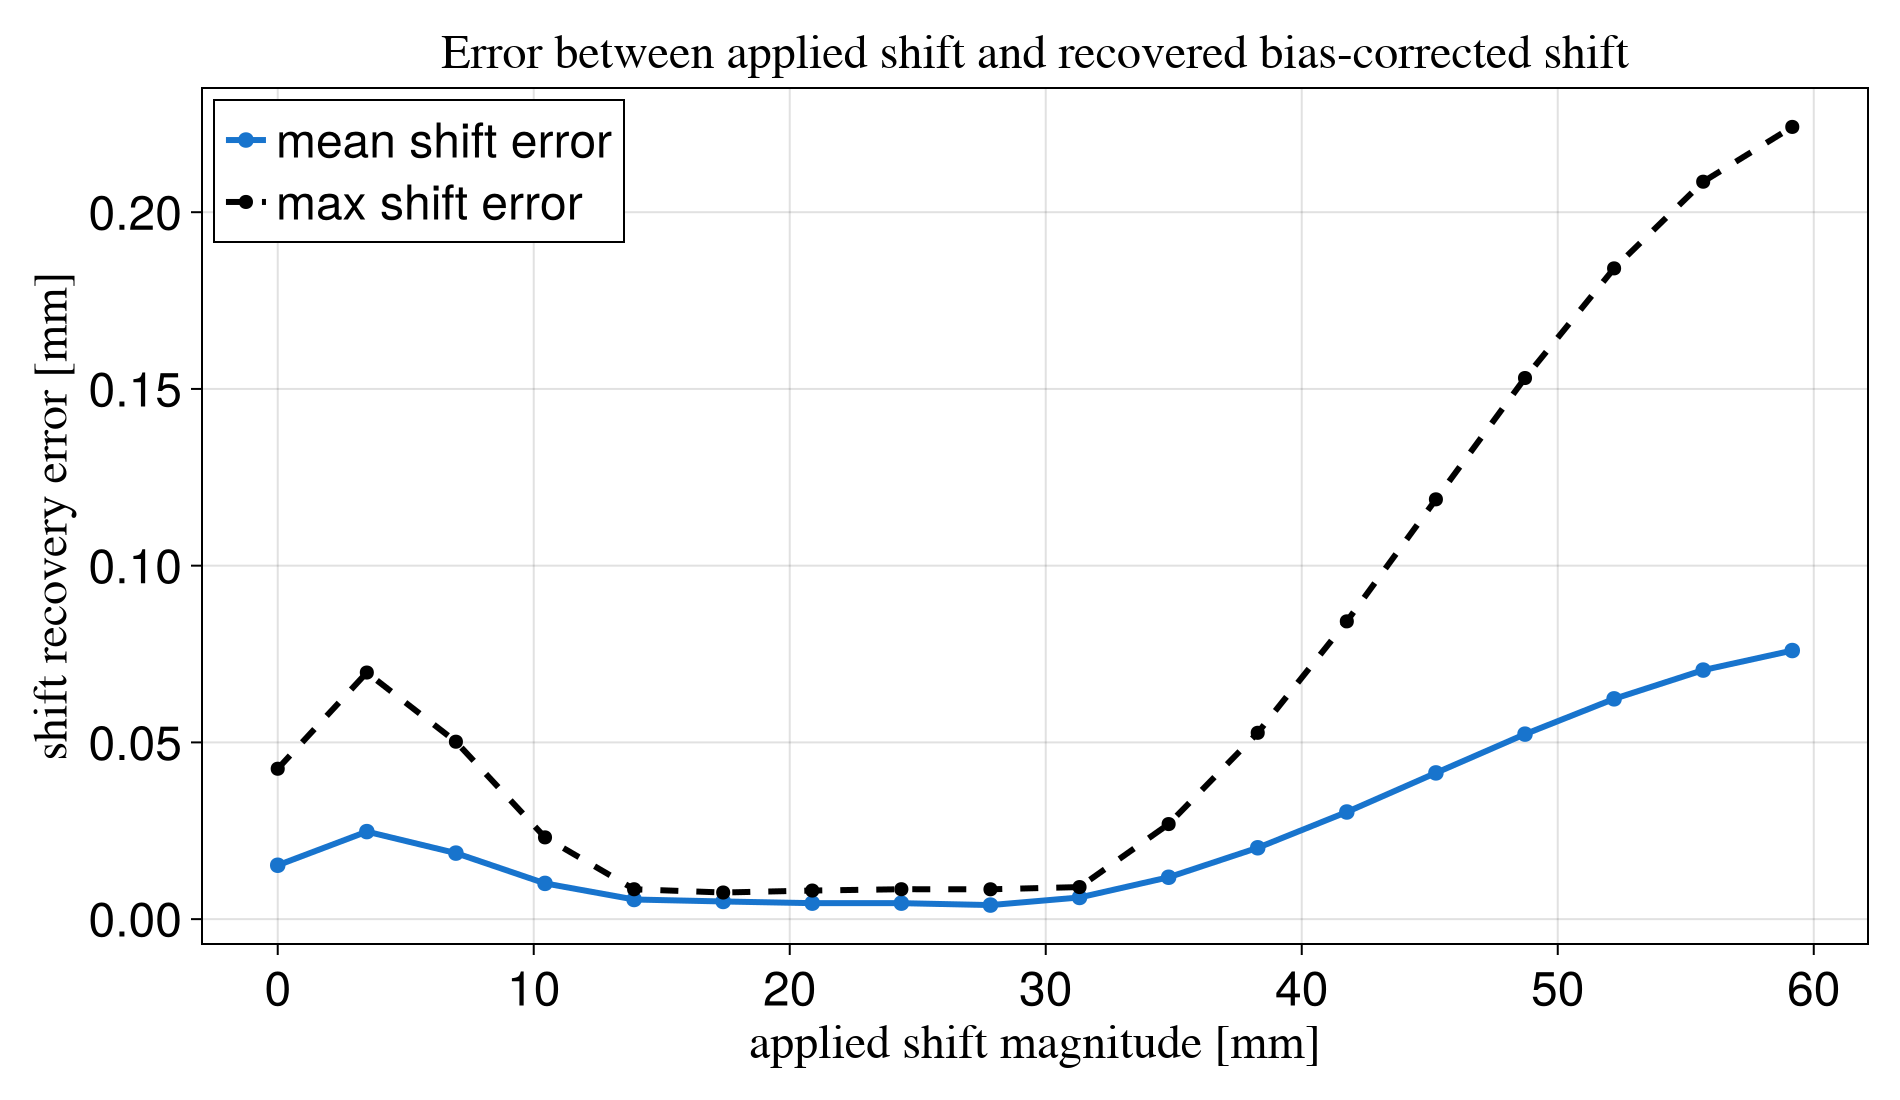

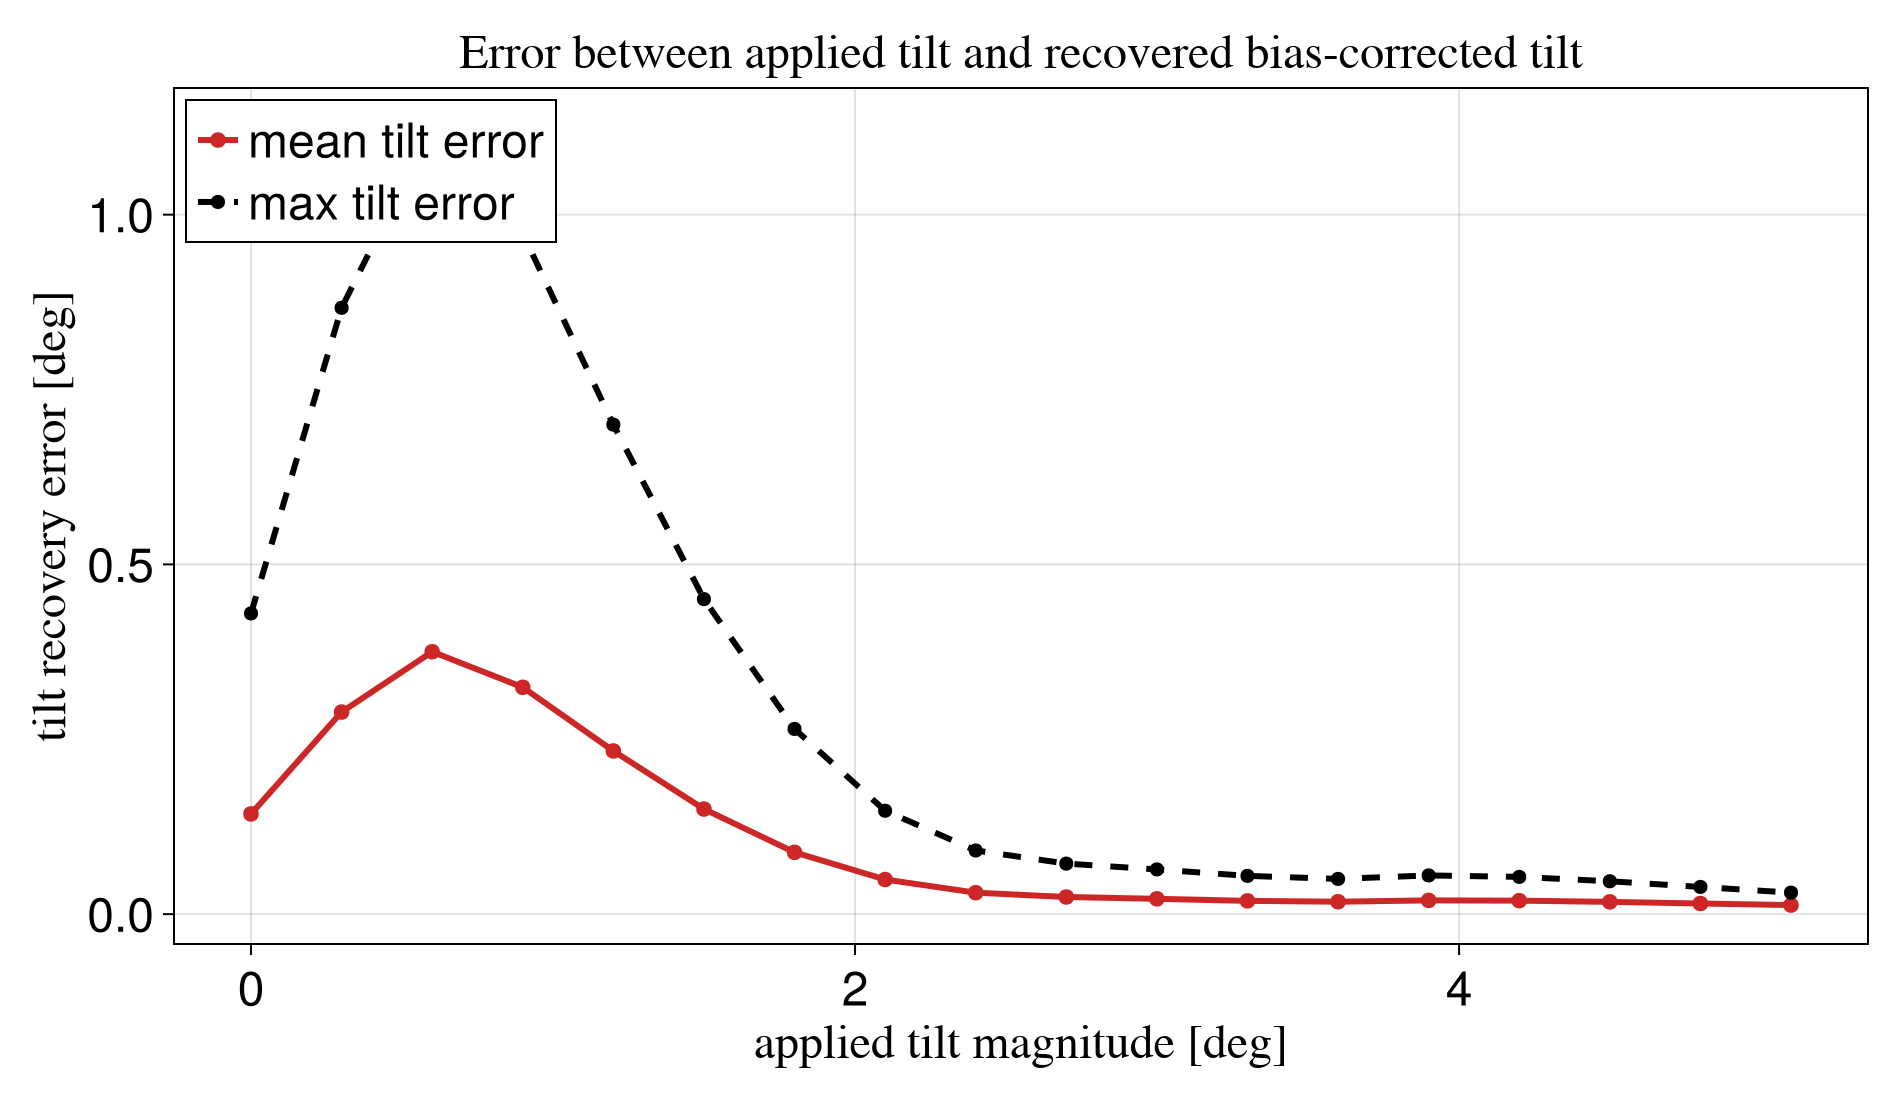

(df_mag_applied = 108×47 DataFrame
 Row │ shift_scale  tilt_scale  layout  nprobes  current_A  input_shift_x_mm   ⋯
     │ Float64      Float64     String  Int64    Float64    Float64            ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │   0.0          0.0       coarse       45      100.0          0.0        ⋯
   2 │   0.0          0.0       medium      180      100.0          0.0
   3 │   0.0          0.0       dense       728      100.0          0.0
   4 │   0.0588235    0.0       coarse       45      100.0          0.588235
   5 │   0.0588235    0.0       medium      180      100.0          0.588235   ⋯
   6 │   0.0588235    0.0       dense       728      100.0          0.588235
   7 │   0.117647     0.0       coarse       45      100.0          1.17647
   8 │   0.117647     0.0       medium      180      100.0          1.17647
  ⋮  │      ⋮           ⋮         ⋮        ⋮         ⋮             ⋮           ⋱
 102 │   0.0          0.88235

In [ ]:
begin
    using CairoMakie
    using DataFrames
    using Statistics

    # ------------------------------------------------------------------
    # Recompute errors relative to APPLIED shifts/tilts,
    # not relative to transformed field geometry.
    #
    # Existing columns:
    #
    # field_geom_dx_mm = field_geom.x0 - phys_geom.x0
    # corr_err_x_mm    = corr.x0       - field_geom.x0
    #
    # Therefore:
    #
    # recovered_dx_mm = corr.x0 - phys_geom.x0
    #                 = corr_err_x_mm + field_geom_dx_mm
    #
    # applied_dx_mm   = input_shift_x_mm
    #
    # applied_error_x_mm = recovered_dx_mm - applied_dx_mm
    # ------------------------------------------------------------------

    df_mag_applied = copy(df_mag)

    # Recovered shifts relative to physical/base geometry
    df_mag_applied.recovered_shift_x_mm =
        df_mag_applied.field_geom_dx_mm .+ df_mag_applied.corr_err_x_mm

    df_mag_applied.recovered_shift_y_mm =
        df_mag_applied.field_geom_dy_mm .+ df_mag_applied.corr_err_y_mm

    df_mag_applied.recovered_shift_z_mm =
        df_mag_applied.field_geom_dz_mm .+ df_mag_applied.corr_err_z_mm

    # Component errors relative to applied shifts
    df_mag_applied.applied_err_shift_x_mm =
        df_mag_applied.recovered_shift_x_mm .- df_mag_applied.input_shift_x_mm

    df_mag_applied.applied_err_shift_y_mm =
        df_mag_applied.recovered_shift_y_mm .- df_mag_applied.input_shift_y_mm

    df_mag_applied.applied_err_shift_z_mm =
        df_mag_applied.recovered_shift_z_mm .- df_mag_applied.input_shift_z_mm

    # 3D shift recovery error relative to applied shift vector
    df_mag_applied.applied_pos_err_mm = sqrt.(
        df_mag_applied.applied_err_shift_x_mm.^2 .+
        df_mag_applied.applied_err_shift_y_mm.^2 .+
        df_mag_applied.applied_err_shift_z_mm.^2
    )

    # Recovered tilts relative to physical/base geometry
    df_mag_applied.recovered_tilt_x_deg =
        df_mag_applied.field_geom_dtx_deg .+ df_mag_applied.corr_err_tilt_x_deg

    df_mag_applied.recovered_tilt_y_deg =
        df_mag_applied.field_geom_dty_deg .+ df_mag_applied.corr_err_tilt_y_deg

    # Component errors relative to applied tilts
    df_mag_applied.applied_err_tilt_x_deg =
        df_mag_applied.recovered_tilt_x_deg .- df_mag_applied.input_tilt_x_deg

    df_mag_applied.applied_err_tilt_y_deg =
        df_mag_applied.recovered_tilt_y_deg .- df_mag_applied.input_tilt_y_deg

    # 2D tilt recovery error relative to applied tilt vector
    # Note: tilt_z is not included because the magnetic-axis method estimates
    # only tilt_x and tilt_y, not rotation around the coil normal.
    df_mag_applied.applied_tilt_err_deg = hypot.(
        df_mag_applied.applied_err_tilt_x_deg,
        df_mag_applied.applied_err_tilt_y_deg,
    )

    # ------------------------------------------------------------------
    # Aggregate shift-only scan
    # ------------------------------------------------------------------

    shift_df_applied = df_mag_applied[
        (df_mag_applied.scan_kind .== "shift_only") .&
        isfinite.(df_mag_applied.input_shift_mag_mm) .&
        isfinite.(df_mag_applied.applied_pos_err_mm),
        :
    ]

    g_shift_applied = combine(
        groupby(shift_df_applied, :input_shift_mag_mm),
        :applied_pos_err_mm => mean    => :mean_applied_pos_err_mm,
        :applied_pos_err_mm => maximum => :max_applied_pos_err_mm,
        nrow => :nruns,
    )

    sort!(g_shift_applied, :input_shift_mag_mm)

    # ------------------------------------------------------------------
    # Aggregate tilt-only scan
    # ------------------------------------------------------------------

    tilt_df_applied = df_mag_applied[
        (df_mag_applied.scan_kind .== "tilt_only") .&
        isfinite.(df_mag_applied.input_tilt_mag_deg) .&
        isfinite.(df_mag_applied.applied_tilt_err_deg),
        :
    ]

    g_tilt_applied = combine(
        groupby(tilt_df_applied, :input_tilt_mag_deg),
        :applied_tilt_err_deg => mean    => :mean_applied_tilt_err_deg,
        :applied_tilt_err_deg => maximum => :max_applied_tilt_err_deg,
        nrow => :nruns,
    )

    sort!(g_tilt_applied, :input_tilt_mag_deg)

    display(g_shift_applied)
    display(g_tilt_applied)

    # ------------------------------------------------------------------
    # Plot 1: applied shift recovery error
    # ------------------------------------------------------------------

    fig_shift_applied = Figure(size = (950, 550))

    ax_shift_applied = Axis(
        fig_shift_applied[1, 1],
        xlabel = "applied shift magnitude [mm]",
        ylabel = "shift recovery error [mm]",
        title = "Error between applied shift and recovered bias-corrected shift",
    )

    scatterlines!(
        ax_shift_applied,
        g_shift_applied.input_shift_mag_mm,
        g_shift_applied.mean_applied_pos_err_mm;
        color = :dodgerblue3,
        markercolor = :dodgerblue3,
        markersize = 11,
        linewidth = 3,
        label = "mean shift error",
    )

    scatterlines!(
        ax_shift_applied,
        g_shift_applied.input_shift_mag_mm,
        g_shift_applied.max_applied_pos_err_mm;
        color = :black,
        markercolor = :black,
        markersize = 10,
        linewidth = 3,
        linestyle = :dash,
        label = "max shift error",
    )

    axislegend(ax_shift_applied, position = :lt)

    # ------------------------------------------------------------------
    # Plot 2: applied tilt recovery error
    # ------------------------------------------------------------------

    fig_tilt_applied = Figure(size = (950, 550))

    ax_tilt_applied = Axis(
        fig_tilt_applied[1, 1],
        xlabel = "applied tilt magnitude [deg]",
        ylabel = "tilt recovery error [deg]",
        title = "Error between applied tilt and recovered bias-corrected tilt",
    )

    scatterlines!(
        ax_tilt_applied,
        g_tilt_applied.input_tilt_mag_deg,
        g_tilt_applied.mean_applied_tilt_err_deg;
        color = :firebrick3,
        markercolor = :firebrick3,
        markersize = 11,
        linewidth = 3,
        label = "mean tilt error",
    )

    scatterlines!(
        ax_tilt_applied,
        g_tilt_applied.input_tilt_mag_deg,
        g_tilt_applied.max_applied_tilt_err_deg;
        color = :black,
        markercolor = :black,
        markersize = 10,
        linewidth = 3,
        linestyle = :dash,
        label = "max tilt error",
    )

    axislegend(ax_tilt_applied, position = :lt)

    display(fig_shift_applied)
    display(fig_tilt_applied)

    (;
        df_mag_applied,
        g_shift_applied,
        g_tilt_applied,
        fig_shift_applied,
        fig_tilt_applied,
    )
end

In [ ]:
println("All done!")

All done!


In [1]:
begin
    using CairoMakie
    using DataFrames
    using Statistics
    using Printf

    # ------------------------------------------------------------
    # Shift / tilt magnitude scan configuration
    # ------------------------------------------------------------

    # About 10–20 x-axis points
    MAGNITUDE_SCAN_SCALES = collect(range(0.0, 2.0, length=18))

    # Choose layouts to include in the statistics.
    # For speed, use only dense or medium.
    # For more robust mean/max, use all three.
    MAGNITUDE_SCAN_LAYOUTS = hall_layouts
    # MAGNITUDE_SCAN_LAYOUTS = [hall_layouts[end]]  # dense only

    # Use one current unless studying noise/current dependence.
    MAGNITUDE_SCAN_CURRENT_A = 100.0

    # Repeats only matter if B_NOISE_ABS_T or B_NOISE_REL is nonzero.
    MAGNITUDE_SCAN_REPEATS = (B_NOISE_ABS_T > 0 || B_NOISE_REL > 0) ? 3 : 1

    # ------------------------------------------------------------
    # Custom analyzer allowing independent shift and tilt scaling
    # ------------------------------------------------------------

    function analyze_one_shift_tilt_magnitude_case(;
        shift_scale,
        tilt_scale,
        layout,
        current_A,
        noise_abs_T = B_NOISE_ABS_T,
        noise_rel = B_NOISE_REL,
        seed = RNG_SEED,
    )
        tag = @sprintf(
            "shift_%05.2f_tilt_%05.2f_%s_I_%g",
            shift_scale,
            tilt_scale,
            layout.name,
            current_A,
        )

        field_file = joinpath(
            SCAN_OUTPUT_DIR,
            "field_magnitude_$(replace(tag, '.' => 'p')).dat",
        )

        sx = shift_scale * BASE_SHIFT_X
        sy = shift_scale * BASE_SHIFT_Y
        sz = shift_scale * BASE_SHIFT_Z

        tx = tilt_scale * BASE_TILT_X_DEG
        ty = tilt_scale * BASE_TILT_Y_DEG
        tz = tilt_scale * BASE_TILT_Z_DEG

        transform_coil_file(
            PHYSICAL_COIL_FILE,
            field_file;
            shift_x = sx,
            shift_y = sy,
            shift_z = sz,
            tilt_x_deg = tx,
            tilt_y_deg = ty,
            tilt_z_deg = tz,
        )

        physical_coils = load_coils(PHYSICAL_COIL_FILE; current_A = current_A)
        field_coils    = load_coils(field_file; current_A = current_A)
        model_coils    = load_coils(PHYSICAL_COIL_FILE; current_A = current_A)

        phys_geom  = axis_from_coil(physical_coils)
        field_geom = axis_from_coil(field_coils)

        h = make_hall_data(
            field_coils,
            phys_geom,
            layout;
            current_A = current_A,
            noise_abs_T = noise_abs_T,
            noise_rel = noise_rel,
            seed = seed,
        )

        raw = run_analysis_pipeline(h, phys_geom)

        corr = bias_correct_axis(
            model_coils,
            h,
            raw.zt1,
            raw.zt2,
            raw.sin1,
            raw.sin2,
        )

        input_shift_mag_mm = 1e3 * sqrt(sx^2 + sy^2 + sz^2)
        input_tilt_mag_deg = sqrt(tx^2 + ty^2 + tz^2)

        field_shift_mag_mm = 1e3 * sqrt(
            (field_geom.x0 - phys_geom.x0)^2 +
            (field_geom.y0 - phys_geom.y0)^2 +
            (field_geom.z0 - phys_geom.z0)^2
        )

        field_tilt_mag_deg = sqrt(
            (field_geom.tilt_x - phys_geom.tilt_x)^2 +
            (field_geom.tilt_y - phys_geom.tilt_y)^2
        )

        return (
            shift_scale = shift_scale,
            tilt_scale = tilt_scale,
            layout = layout.name,
            nprobes = layout.nphi_i * layout.nz_i + layout.nphi_o * layout.nz_o,
            current_A = current_A,

            input_shift_x_mm = sx * 1e3,
            input_shift_y_mm = sy * 1e3,
            input_shift_z_mm = sz * 1e3,
            input_shift_mag_mm = input_shift_mag_mm,

            input_tilt_x_deg = tx,
            input_tilt_y_deg = ty,
            input_tilt_z_deg = tz,
            input_tilt_mag_deg = input_tilt_mag_deg,

            field_shift_mag_mm = field_shift_mag_mm,
            field_tilt_mag_deg = field_tilt_mag_deg,

            field_geom_dx_mm = (field_geom.x0 - phys_geom.x0) * 1e3,
            field_geom_dy_mm = (field_geom.y0 - phys_geom.y0) * 1e3,
            field_geom_dz_mm = (field_geom.z0 - phys_geom.z0) * 1e3,
            field_geom_dtx_deg = field_geom.tilt_x - phys_geom.tilt_x,
            field_geom_dty_deg = field_geom.tilt_y - phys_geom.tilt_y,

            raw_err_x_mm = (raw.sinavg.x0 - field_geom.x0) * 1e3,
            raw_err_y_mm = (raw.sinavg.y0 - field_geom.y0) * 1e3,
            raw_err_z_mm = (raw.sinavg.z0 - field_geom.z0) * 1e3,
            raw_err_tilt_x_deg = raw.sinavg.tilt_x - field_geom.tilt_x,
            raw_err_tilt_y_deg = raw.sinavg.tilt_y - field_geom.tilt_y,

            corr_err_x_mm = (corr.x0 - field_geom.x0) * 1e3,
            corr_err_y_mm = (corr.y0 - field_geom.y0) * 1e3,
            corr_err_z_mm = (corr.z0 - field_geom.z0) * 1e3,
            corr_err_tilt_x_deg = corr.tilt_x - field_geom.tilt_x,
            corr_err_tilt_y_deg = corr.tilt_y - field_geom.tilt_y,

            corr_pos_err_mm = sqrt(
                ((corr.x0 - field_geom.x0) * 1e3)^2 +
                ((corr.y0 - field_geom.y0) * 1e3)^2 +
                ((corr.z0 - field_geom.z0) * 1e3)^2
            ),

            corr_tilt_err_deg = hypot(
                corr.tilt_x - field_geom.tilt_x,
                corr.tilt_y - field_geom.tilt_y,
            ),

            raw_pos_err_mm = sqrt(
                ((raw.sinavg.x0 - field_geom.x0) * 1e3)^2 +
                ((raw.sinavg.y0 - field_geom.y0) * 1e3)^2 +
                ((raw.sinavg.z0 - field_geom.z0) * 1e3)^2
            ),

            raw_tilt_err_deg = hypot(
                raw.sinavg.tilt_x - field_geom.tilt_x,
                raw.sinavg.tilt_y - field_geom.tilt_y,
            ),
        )
    end

    # ------------------------------------------------------------
    # Run separated magnitude scans
    # ------------------------------------------------------------

    rows_mag = NamedTuple[]

    total_mag_cases =
        2 *
        length(MAGNITUDE_SCAN_SCALES) *
        length(MAGNITUDE_SCAN_LAYOUTS) *
        MAGNITUDE_SCAN_REPEATS

    case_idx_mag = 0

    for scan_kind in ["shift_only", "tilt_only"]
        for scale in MAGNITUDE_SCAN_SCALES
            for layout in MAGNITUDE_SCAN_LAYOUTS
                for rep in 1:MAGNITUDE_SCAN_REPEATS
                    global case_idx_mag += 1

                    shift_scale = scan_kind == "shift_only" ? scale : 0.0
                    tilt_scale  = scan_kind == "tilt_only"  ? scale : 0.0

                    @printf(
                        "[%d/%d] %s scale=%.3f layout=%s nprobes=%d I=%.1f A repeat=%d\n",
                        case_idx_mag,
                        total_mag_cases,
                        scan_kind,
                        scale,
                        layout.name,
                        layout.nphi_i * layout.nz_i + layout.nphi_o * layout.nz_o,
                        MAGNITUDE_SCAN_CURRENT_A,
                        rep,
                    )

                    try
                        row = analyze_one_shift_tilt_magnitude_case(
                            shift_scale = shift_scale,
                            tilt_scale = tilt_scale,
                            layout = layout,
                            current_A = MAGNITUDE_SCAN_CURRENT_A,
                            seed = RNG_SEED + 20_000 + case_idx_mag,
                        )

                        push!(rows_mag, merge(row, (scan_kind = scan_kind,)))
                    catch err
                        @warn "magnitude scan case failed" scan_kind scale layout=layout.name rep exception=(err, catch_backtrace())
                    end
                end
            end
        end
    end

    df_mag = DataFrame(rows_mag)

    csv_mag_path = joinpath(SCAN_OUTPUT_DIR, "coil_centering_shift_tilt_magnitude_scan_results.csv")
    CSV.write(csv_mag_path, df_mag)

    println("Saved: ", csv_mag_path)

    # ------------------------------------------------------------
    # Aggregate shift-only scan
    # ------------------------------------------------------------

    shift_df = df_mag[
        (df_mag.scan_kind .== "shift_only") .&
        isfinite.(df_mag.input_shift_mag_mm) .&
        isfinite.(df_mag.corr_pos_err_mm) .&
        isfinite.(df_mag.corr_tilt_err_deg),
        :
    ]

    g_shift = combine(
        groupby(shift_df, :input_shift_mag_mm),
        :corr_pos_err_mm => mean    => :mean_pos_err_mm,
        :corr_pos_err_mm => maximum => :max_pos_err_mm,
        :corr_tilt_err_deg => mean    => :mean_tilt_err_deg,
        :corr_tilt_err_deg => maximum => :max_tilt_err_deg,
        nrow => :nruns,
    )

    sort!(g_shift, :input_shift_mag_mm)

    # ------------------------------------------------------------
    # Aggregate tilt-only scan
    # ------------------------------------------------------------

    tilt_df = df_mag[
        (df_mag.scan_kind .== "tilt_only") .&
        isfinite.(df_mag.input_tilt_mag_deg) .&
        isfinite.(df_mag.corr_pos_err_mm) .&
        isfinite.(df_mag.corr_tilt_err_deg),
        :
    ]

    g_tilt = combine(
        groupby(tilt_df, :input_tilt_mag_deg),
        :corr_pos_err_mm => mean    => :mean_pos_err_mm,
        :corr_pos_err_mm => maximum => :max_pos_err_mm,
        :corr_tilt_err_deg => mean    => :mean_tilt_err_deg,
        :corr_tilt_err_deg => maximum => :max_tilt_err_deg,
        nrow => :nruns,
    )

    sort!(g_tilt, :input_tilt_mag_deg)

    display(g_shift)
    display(g_tilt)

    # ------------------------------------------------------------
    # Plot 1: position error vs applied shift magnitude
    # ------------------------------------------------------------

    fig_shift_pos = Figure(size = (950, 550))

    ax_shift_pos = Axis(
        fig_shift_pos[1, 1],
        xlabel = "applied shift magnitude [mm]",
        ylabel = "position error [mm]",
        title = "Position recovery error vs applied shift magnitude",
    )

    scatterlines!(
        ax_shift_pos,
        g_shift.input_shift_mag_mm,
        g_shift.mean_pos_err_mm;
        color = :dodgerblue3,
        markercolor = :dodgerblue3,
        markersize = 11,
        linewidth = 3,
        label = "mean position error",
    )

    scatterlines!(
        ax_shift_pos,
        g_shift.input_shift_mag_mm,
        g_shift.max_pos_err_mm;
        color = :black,
        markercolor = :black,
        markersize = 10,
        linewidth = 3,
        linestyle = :dash,
        label = "max position error",
    )

    axislegend(ax_shift_pos, position = :lt)

    # ------------------------------------------------------------
    # Plot 2: tilt error vs applied tilt magnitude
    # ------------------------------------------------------------

    fig_tilt_tilt = Figure(size = (950, 550))

    ax_tilt_tilt = Axis(
        fig_tilt_tilt[1, 1],
        xlabel = "applied tilt magnitude [deg]",
        ylabel = "tilt error [deg]",
        title = "Tilt recovery error vs applied tilt magnitude",
    )

    scatterlines!(
        ax_tilt_tilt,
        g_tilt.input_tilt_mag_deg,
        g_tilt.mean_tilt_err_deg;
        color = :firebrick3,
        markercolor = :firebrick3,
        markersize = 11,
        linewidth = 3,
        label = "mean tilt error",
    )

    scatterlines!(
        ax_tilt_tilt,
        g_tilt.input_tilt_mag_deg,
        g_tilt.max_tilt_err_deg;
        color = :black,
        markercolor = :black,
        markersize = 10,
        linewidth = 3,
        linestyle = :dash,
        label = "max tilt error",
    )

    axislegend(ax_tilt_tilt, position = :lt)

    # ------------------------------------------------------------
    # Optional cross-coupling plots
    # ------------------------------------------------------------

    fig_shift_tilt = Figure(size = (950, 550))

    ax_shift_tilt = Axis(
        fig_shift_tilt[1, 1],
        xlabel = "applied shift magnitude [mm]",
        ylabel = "tilt error [deg]",
        title = "Tilt error induced during shift-only scan",
    )

    scatterlines!(
        ax_shift_tilt,
        g_shift.input_shift_mag_mm,
        g_shift.mean_tilt_err_deg;
        color = :firebrick3,
        markercolor = :firebrick3,
        markersize = 11,
        linewidth = 3,
        label = "mean tilt error",
    )

    scatterlines!(
        ax_shift_tilt,
        g_shift.input_shift_mag_mm,
        g_shift.max_tilt_err_deg;
        color = :black,
        markercolor = :black,
        markersize = 10,
        linewidth = 3,
        linestyle = :dash,
        label = "max tilt error",
    )

    axislegend(ax_shift_tilt, position = :lt)

    fig_tilt_pos = Figure(size = (950, 550))

    ax_tilt_pos = Axis(
        fig_tilt_pos[1, 1],
        xlabel = "applied tilt magnitude [deg]",
        ylabel = "position error [mm]",
        title = "Position error induced during tilt-only scan",
    )

    scatterlines!(
        ax_tilt_pos,
        g_tilt.input_tilt_mag_deg,
        g_tilt.mean_pos_err_mm;
        color = :dodgerblue3,
        markercolor = :dodgerblue3,
        markersize = 11,
        linewidth = 3,
        label = "mean position error",
    )

    scatterlines!(
        ax_tilt_pos,
        g_tilt.input_tilt_mag_deg,
        g_tilt.max_pos_err_mm;
        color = :black,
        markercolor = :black,
        markersize = 10,
        linewidth = 3,
        linestyle = :dash,
        label = "max position error",
    )

    axislegend(ax_tilt_pos, position = :lt)

    display(fig_shift_pos)
    display(fig_tilt_tilt)
    display(fig_shift_tilt)
    display(fig_tilt_pos)

    (;
        df_mag,
        g_shift,
        g_tilt,
        fig_shift_pos,
        fig_tilt_tilt,
        fig_shift_tilt,
        fig_tilt_pos,
    )
end

LoadError: LoadError: UndefVarError: `@sprintf` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
Hint: a global variable of this name also exists in Printf.
in expression starting at /Users/bursche/Documents/GitHub/JULIA_GPEC/examples/Br_3D_example/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X41sZmlsZQ==.jl:39